In [1]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from PIL import Image


# Projeto 2 - Sinais e Sistemas em Tempo Discreto - 2023/01
# Identificação
## Nome: Andreza Rodrigues Costa
## Matrícula: 180074474

# Funções utilizadas.

Coloque abaixo as funções desenvolvidas para este projeto.

In [2]:
# Código das funções utilizadas.

recursive_optimization_matrix = [["x" for j in range(5000)] for i in range(5000)]

k, a0, a1, a2, a3, b0, b1, b2, b3 = 0, 0, 0, 0, 0, 0, 0, 0, 0

def y_1d(n, x):
    if n <= 1:
        return 0

    if recursive_optimization_matrix[n][n] != "x":
        return recursive_optimization_matrix[n][n]

    solution = (
        k * (b0 * x[n] + b1 * x[n - 1] + b2 * x[n - 2])
        - a1 * y_1d(n - 1, x)
        - a2 * y_1d(n - 2, x)
    )

    recursive_optimization_matrix[n][n] = solution

    return solution

def y_2d(n, x):
    if n <= 1:
        return 0

    if recursive_optimization_matrix[n][n] != "x":
        return recursive_optimization_matrix[n][n]

    solution = (
        k * (b0 * x[n] + b1 * x[n - 1] + b2 * x[n - 2] + b3 * x[n - 3])
        - a1 * y_2d(n - 1, x)
        - a2 * y_2d(n - 2, x)
        - a3 * y_2d(n - 3, x)
    )

    recursive_optimization_matrix[n][n] = solution

    return solution

def restaurar_matriz_recursiva():
    for i in range(5000):
        for j in range(5000):
            recursive_optimization_matrix[i][j] = "x"


# Questão 1

Um sistema de aquisição de dados de eletrocardiograma foi ligado de forma equivocada perto demais da rede elétrica. Assim, a interferência da rede elétrica (a 60 Hz) aparece de forma marcante no sinal adquirido. O seu objetivo é projetar um filtro digital para eliminar totalmente o ruído em 60Hz. A frequência de amostragem do sistema é:

$$ f_a = 500~Hz $$

Siga as questões abaixo.

## Questão 1a (0.5  pontos)

Projete o filtro em questão utilizando a colocação de pólos e zeros no plano z. Desenhe o diagrama de pólos e zeros do filtro projetado, indicando quais pólos e zeros foram indicados e o porquê destes pólos/zeros terem sido escolhidos. Você pode inserir o seu projeto como uma imagem escaneada abaixo.

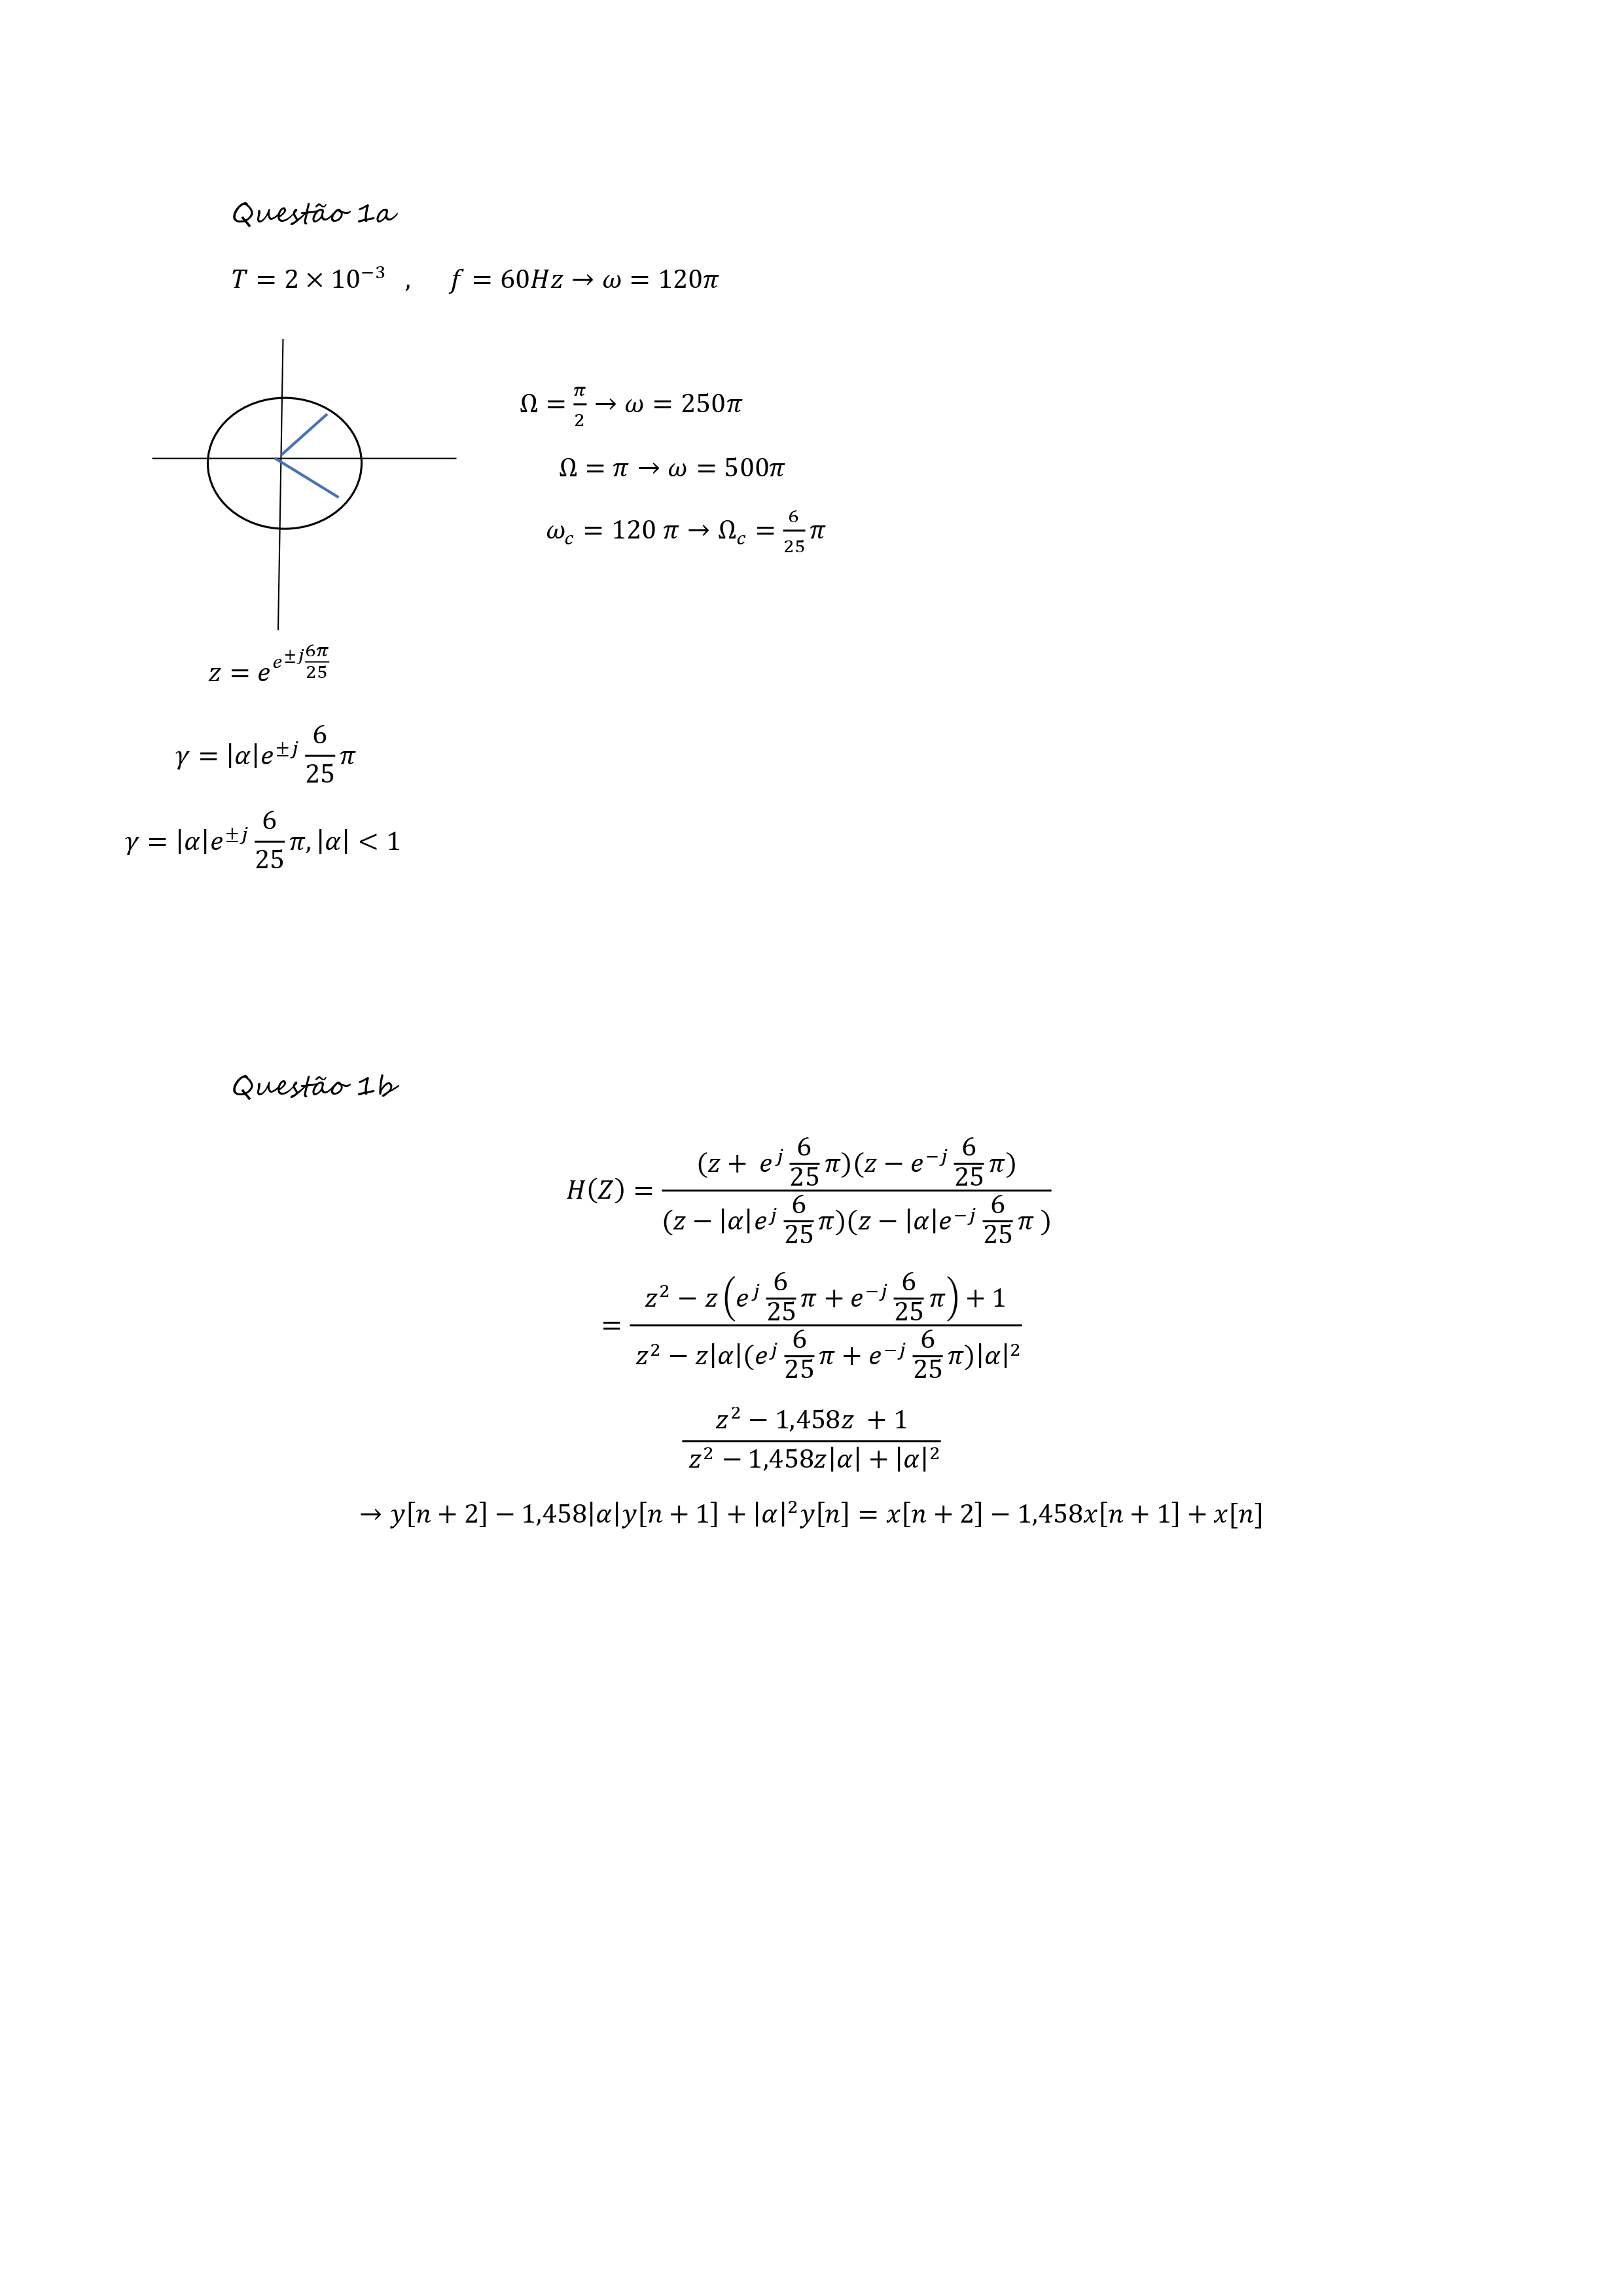

In [ ]:
# Código da questão 1a
Image.open("./1a,1b.jpg")






## Questão 1b (0.5 pontos)

A partir do diagrama desenvolvido na questão anterior, escreva a função de transferência do filtro H(z) e a equação de diferenças do sistema que realiza o filtro. Você pode inserir sua resposta como uma imagem escaneada abaixo.

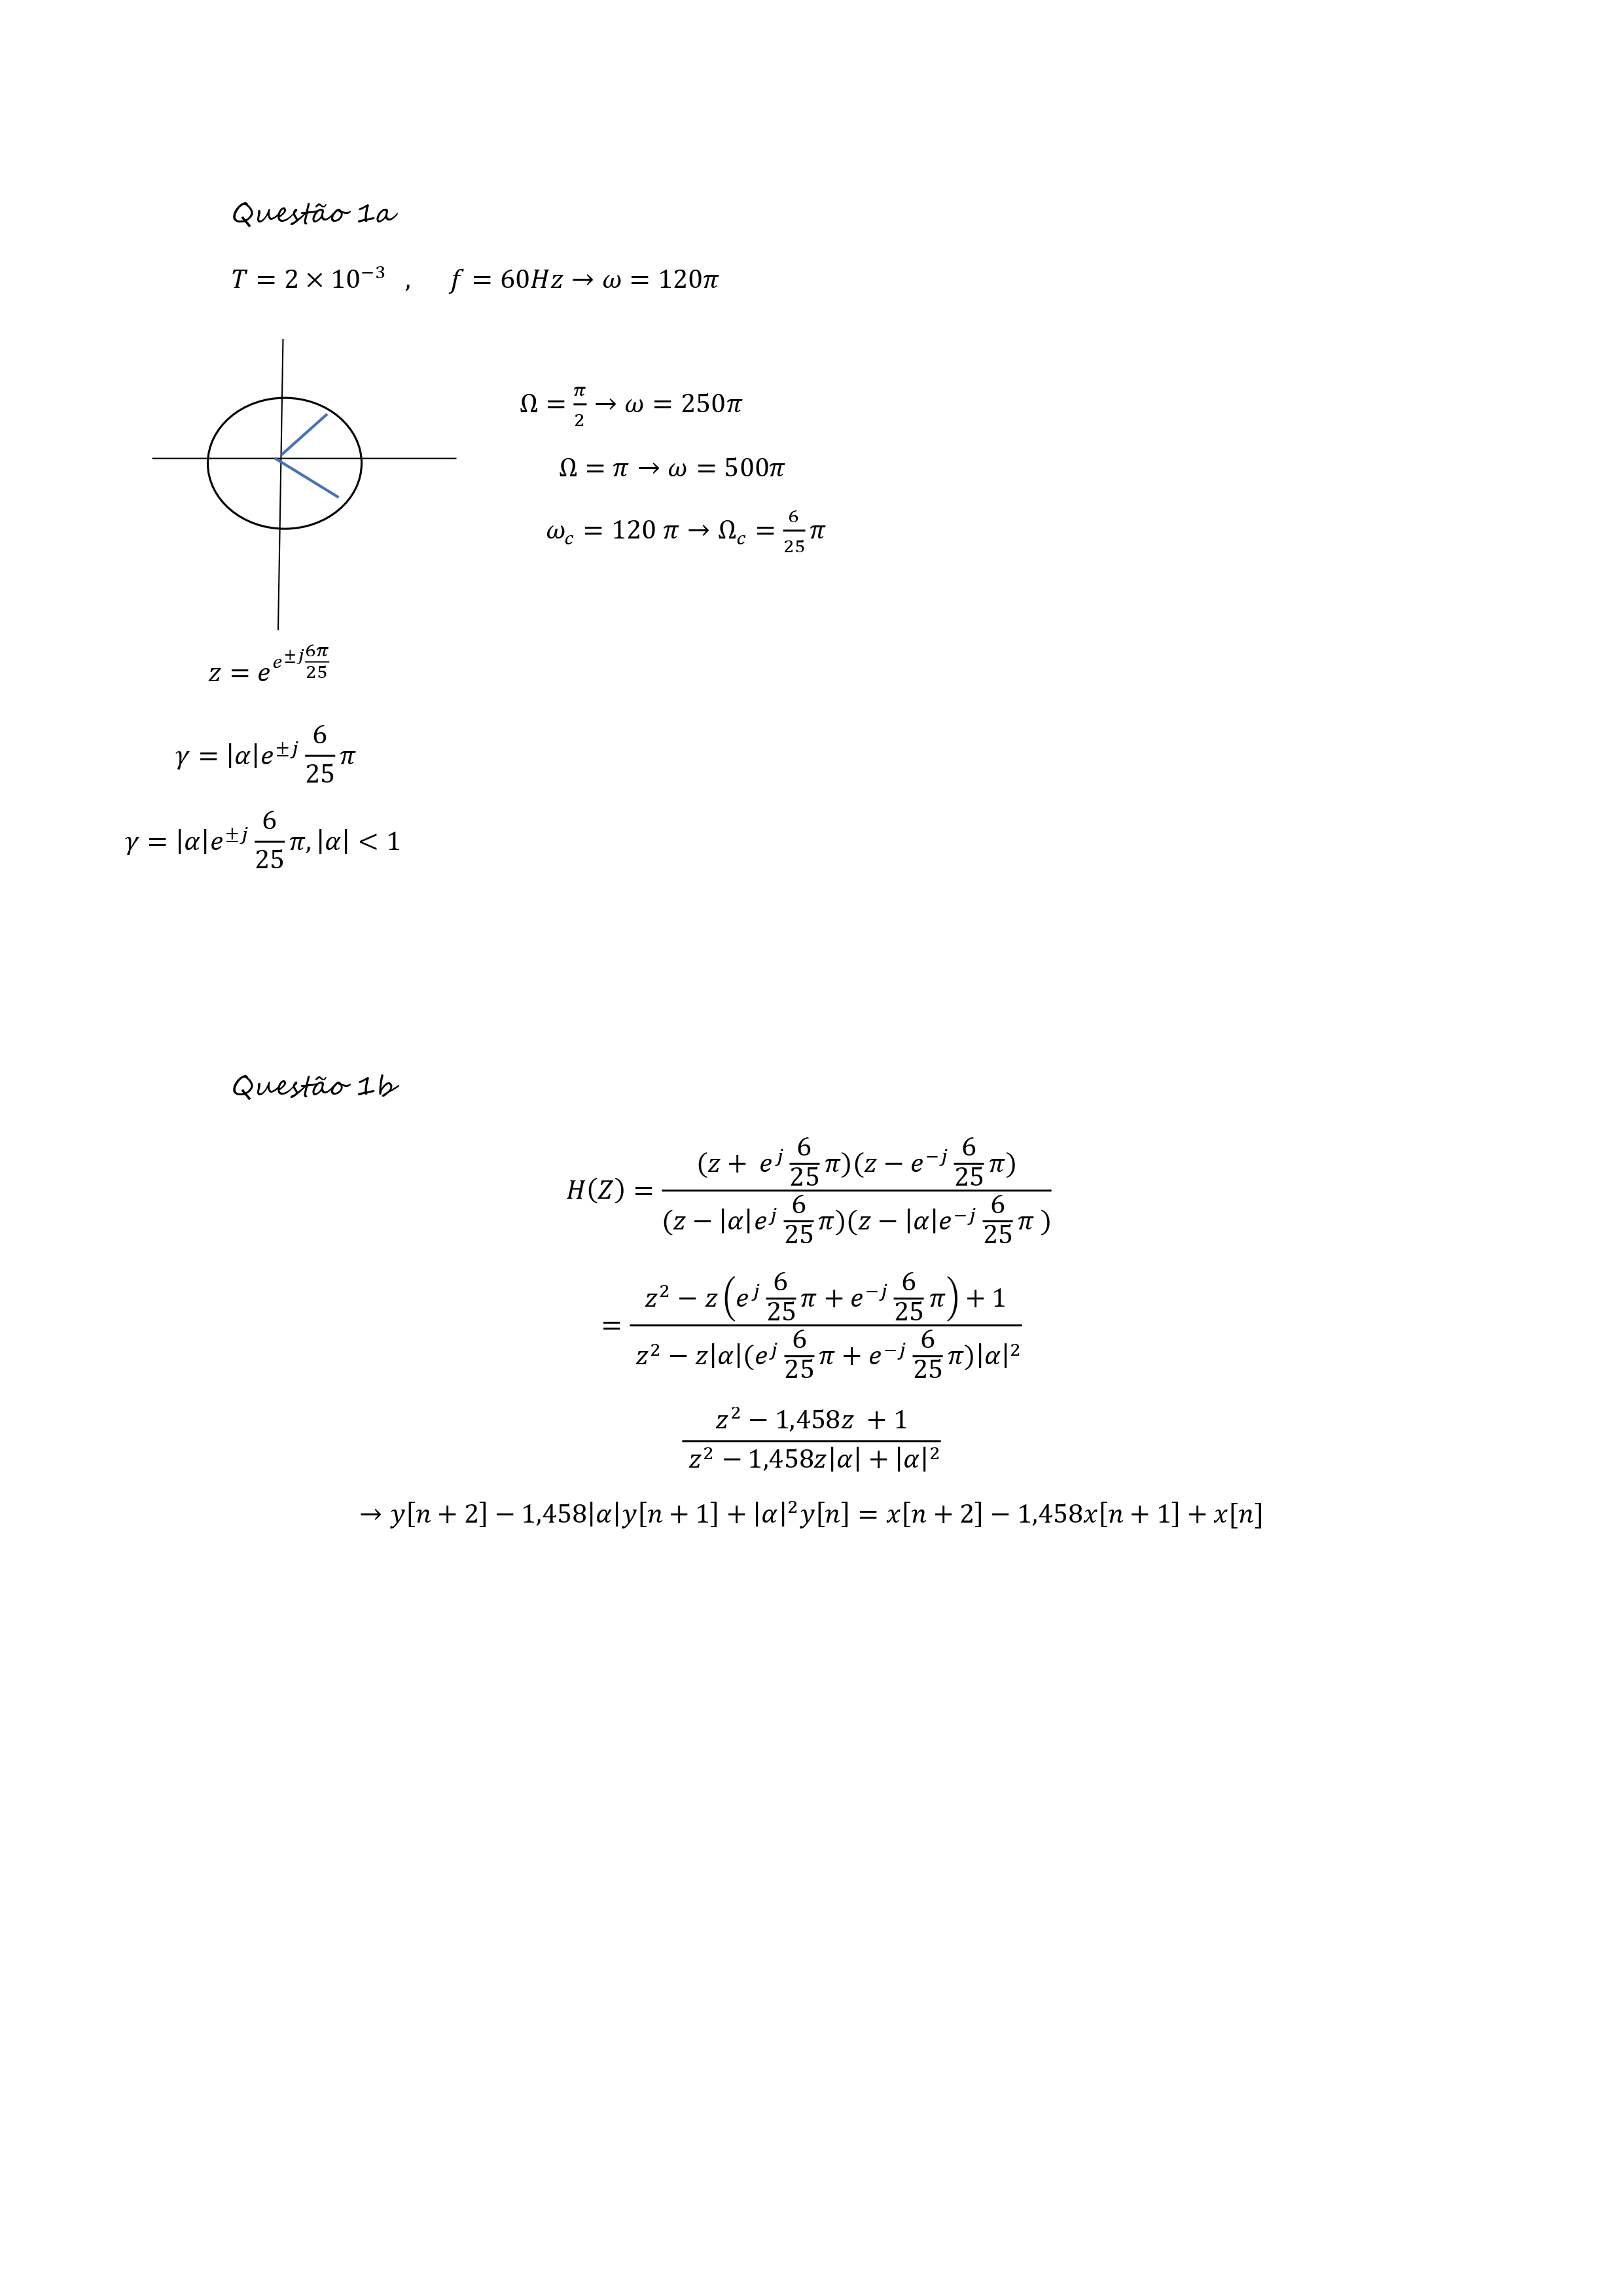

In [ ]:
# Código da questão 1b

Image.open("./1a,1b.jpg")



## Questão 1c (1  ponto)

Plote a **resposta em frequência** do filtro projetado (magnitude e fase).

<>:45: SyntaxWarning: invalid escape sequence '\O'
<>:46: SyntaxWarning: invalid escape sequence '\O'
<>:55: SyntaxWarning: invalid escape sequence '\O'
<>:56: SyntaxWarning: invalid escape sequence '\O'
<>:64: SyntaxWarning: invalid escape sequence '\O'
<>:65: SyntaxWarning: invalid escape sequence '\O'
<>:45: SyntaxWarning: invalid escape sequence '\O'
<>:46: SyntaxWarning: invalid escape sequence '\O'
<>:55: SyntaxWarning: invalid escape sequence '\O'
<>:56: SyntaxWarning: invalid escape sequence '\O'
<>:64: SyntaxWarning: invalid escape sequence '\O'
<>:65: SyntaxWarning: invalid escape sequence '\O'
C:\Users\admin\AppData\Local\Temp\ipykernel_16088\3872802848.py:45: SyntaxWarning: invalid escape sequence '\O'
  plt.title("Resposta em Frequência de $H(e^{j\Omega})$")
C:\Users\admin\AppData\Local\Temp\ipykernel_16088\3872802848.py:46: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel("Frequência angular $\Omega$")
C:\Users\admin\AppData\Local\Temp\ipykernel_16088\3872802848.p

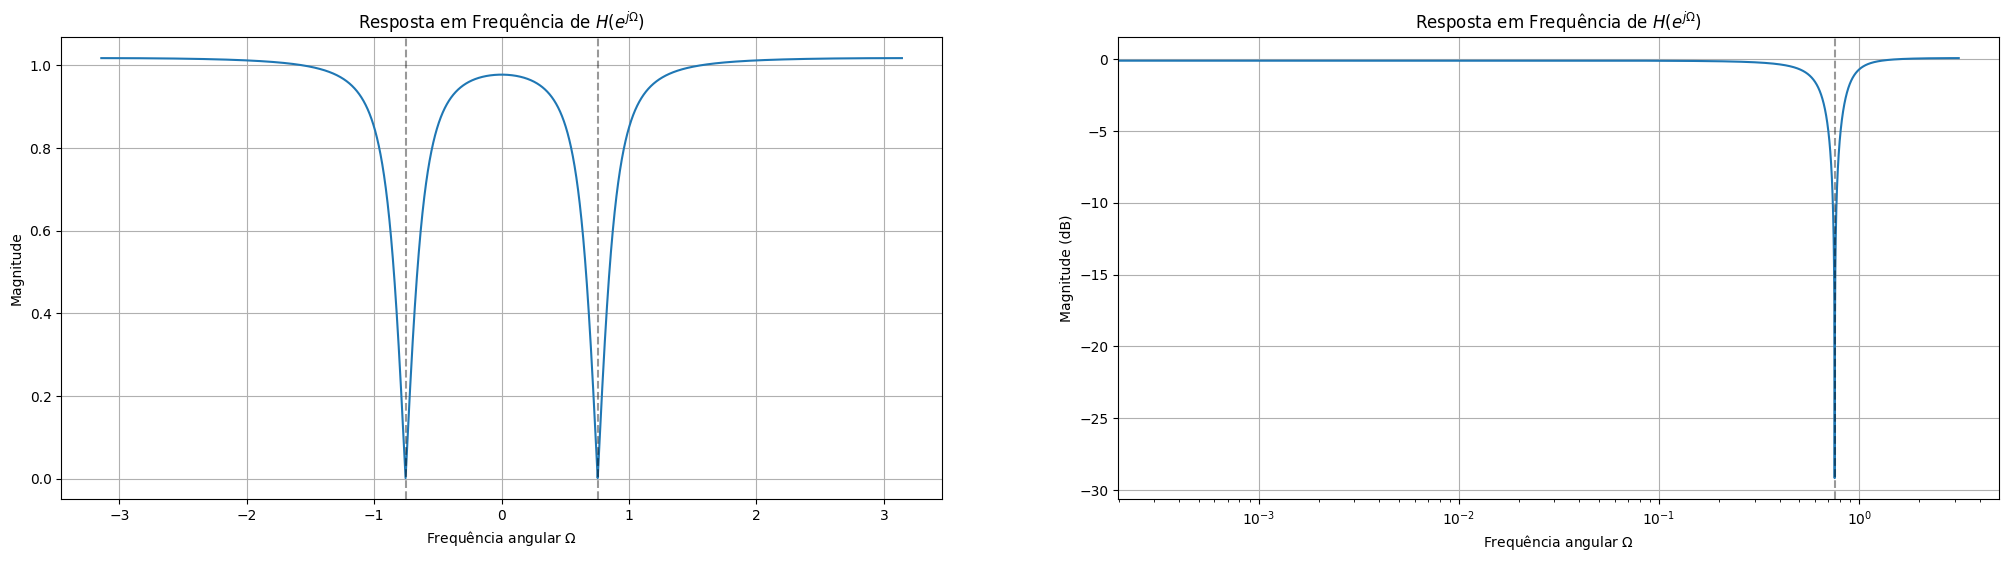

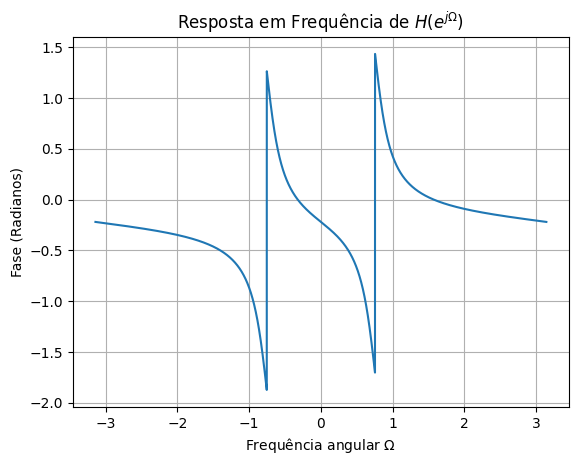

In [3]:

# Resposta da questão 1c
ALPHA = 0.85

# Frequência de corte
wc = 6 / 25 * np.pi

# Coeficientes do filtro
b0, b1, b2 = 1, -1.458, 1
a0, a1, a2 = 1, -1.458 * ALPHA, ALPHA**2

# Função para calcular a constante de ganho do filtro
def calcular_constante_ganho(wc, ALPHA):
    z = np.exp(1j * (np.pi / 2))
    numerador = (z - ALPHA * np.exp(1j * wc)) * (z - ALPHA * np.exp(-1j * wc))
    denominador = (z - np.exp(1j * wc)) * (z - np.exp(-1j * wc))
    return numerador / denominador

# Função para calcular a resposta em frequência
def calcular_resposta_frequencia(w, wc, k, b0, b1, b2, a0, a1, a2):
    w_axis = np.exp(1j * w)
    numerador = k * (b0 * w_axis**2 + b1 * w_axis + b2)
    denominador = a0 * w_axis**2 + a1 * w_axis + a2
    return numerador / denominador

# Cálculo da constante de ganho
k = calcular_constante_ganho(wc, ALPHA)

# Geração do eixo de frequência
w = np.linspace(-np.pi, np.pi, 10000)

# Cálculo da resposta em frequência
H = calcular_resposta_frequencia(w, wc, k, b0, b1, b2, a0, a1, a2)

# Cálculo da magnitude, fase e magnitude em dB da resposta em frequência
H_abs = abs(H)
H_phase = np.angle(H)
H_mag_db = 10 * np.log10(abs(H))

# Plotagem da magnitude da resposta em frequência
plt.figure(figsize=(25,6))
plt.subplot(1,2,1)
plt.plot(w, H_abs)
plt.axvline(x=wc, linestyle="--", color="black", alpha=0.4)
plt.axvline(x=-wc, linestyle="--", color="black", alpha=0.4)
plt.title("Resposta em Frequência de $H(e^{j\Omega})$")
plt.xlabel("Frequência angular $\Omega$")
plt.ylabel("Magnitude")
plt.grid()

# Plotagem da magnitude em dB da resposta em frequência
plt.subplot(1,2,2)
plt.plot(w, H_mag_db)
plt.axvline(x=wc, linestyle="--", color="black", alpha=0.4)
plt.axvline(x=-wc, linestyle="--", color="black", alpha=0.4)
plt.title("Resposta em Frequência de $H(e^{j\Omega})$")
plt.xlabel("Frequência angular $\Omega$")
plt.ylabel("Magnitude (dB)")
plt.xscale("log")
plt.grid()
plt.show()

# Plotagem da fase da resposta em frequência
plt.plot(w, H_phase)
plt.title("Resposta em Frequência de $H(e^{j\Omega})$")
plt.xlabel("Frequência angular $\Omega$")
plt.ylabel("Fase (Radianos)")
plt.grid()
plt.show()













## Questão 1d (0.5  pontos)

Carregue o sinal de ECG "noisy_ecg_data.mat" e aplique o filtro projetado neste sinal. Plote o sinal antes da filtragem (x[n]) e o sinal após a filtragem (y[n]).

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


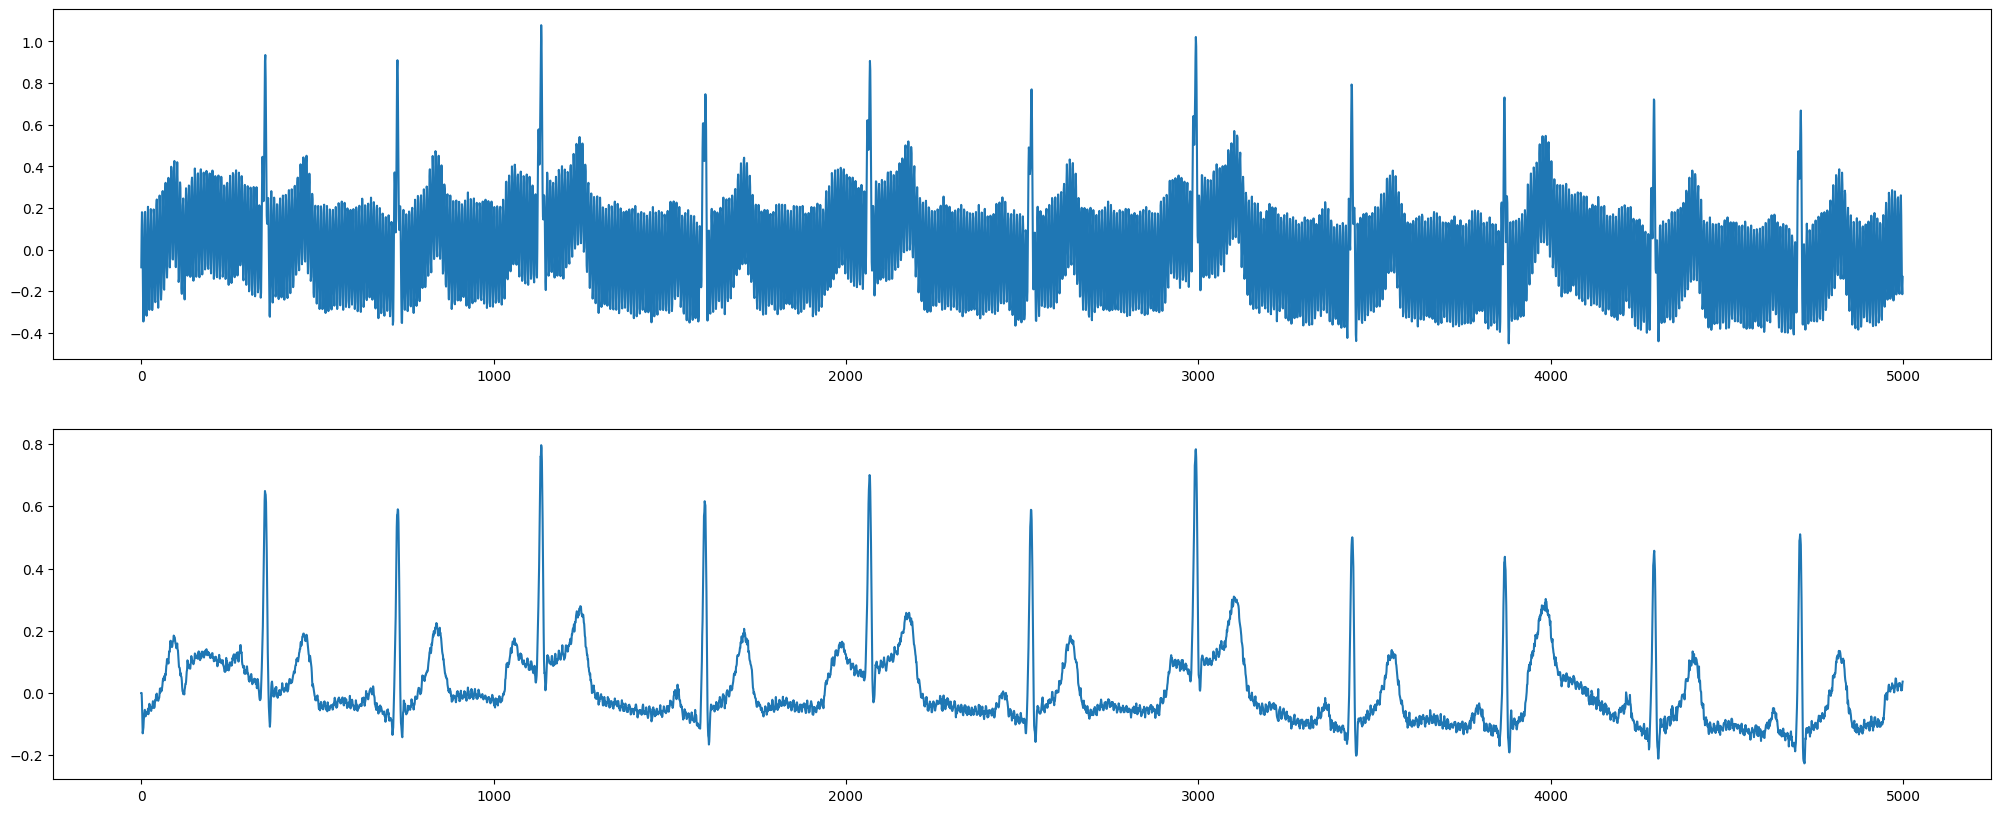

In [4]:
# Resposta  da questão 1d

sinal = sp.io.loadmat("noisy_ecg_data.mat")["noisy_ecg"].ravel()

x_1d = [sinal[n] for n in range(len(sinal))]

restaurar_matriz_recursiva()

y_1d_sinal = [y_1d(n, x_1d) for n in range(len(sinal))]

plt.figure(figsize=(25, 10))

plt.subplot(2, 1, 1)
plt.plot(x_1d)

plt.subplot(2, 1, 2)
plt.plot(y_1d_sinal)




# Questão 2

Ainda no sistema de aquisição de dados de eletrocardiograma, mais tarde foi verificado que, mesmo depois de resolvido o problema da interferência da rede elétrica (i.e., o sinal não tem um ruído específico em 60Hz), o sinal adquirido tinha bastante ruído de alta frequência (acima de 35Hz). O objetivo desta questão é projetar um filtro digital para atenuar as frequências acima de 35Hz. A frequêencia de amostragem do sistema é:

$$ f_a = 500~Hz $$

Siga as questões abaixo.

## Questão 2a (0.5  pontos)

Projete o filtro em questão utilizando a colocação de pólos e zeros no plano z. Desenhe o diagrama de pólos e zeros do filtro projetado, indicando quais pólos e zeros foram indicados e o porquê destes pólos/zeros terem sido escolhidos. Você pode inserir o seu projeto como uma imagem escaneada abaixo.

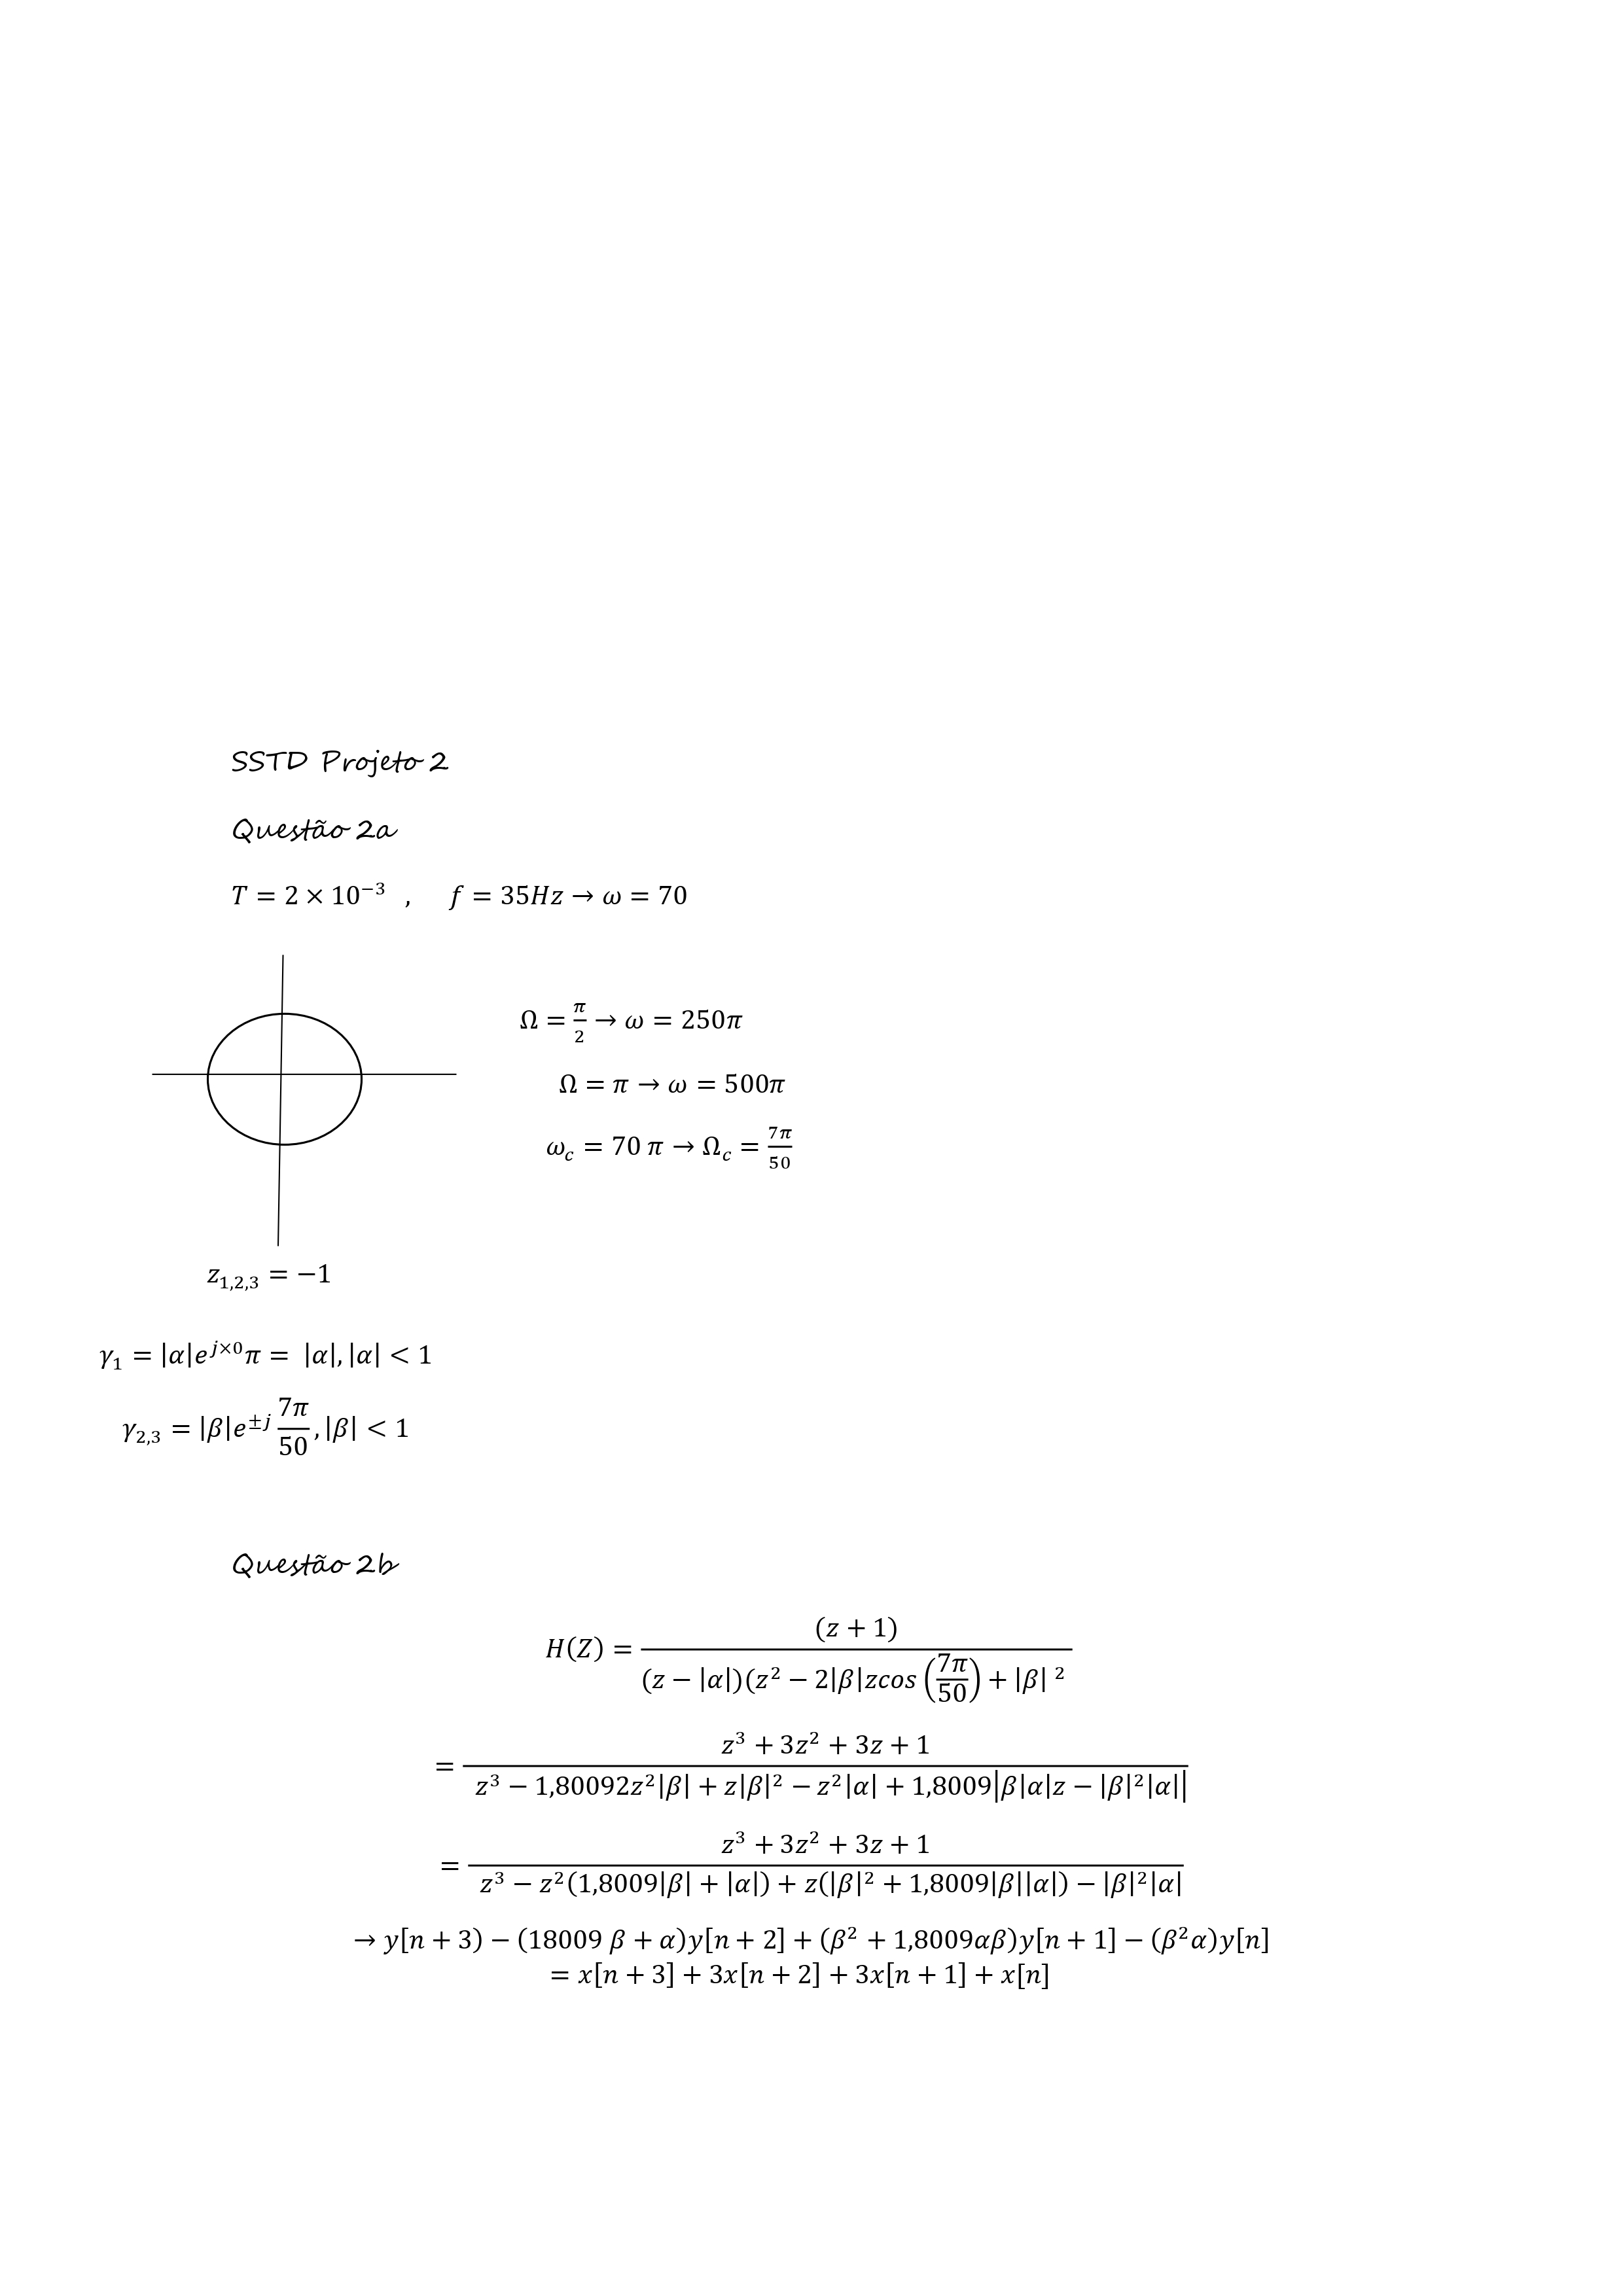

In [ ]:
# Resposta da questão 2a

Image.open("./2a,b.jpg")




## Questão 2b (0.5 pontos)

A partir do diagrama desenvolvido na questão anterior, escreva a função de transferência do filtro H(z) e a equação de diferenças do sistema que realiza o filtro. Você pode inserir sua resposta como uma imagem escaneada abaixo.

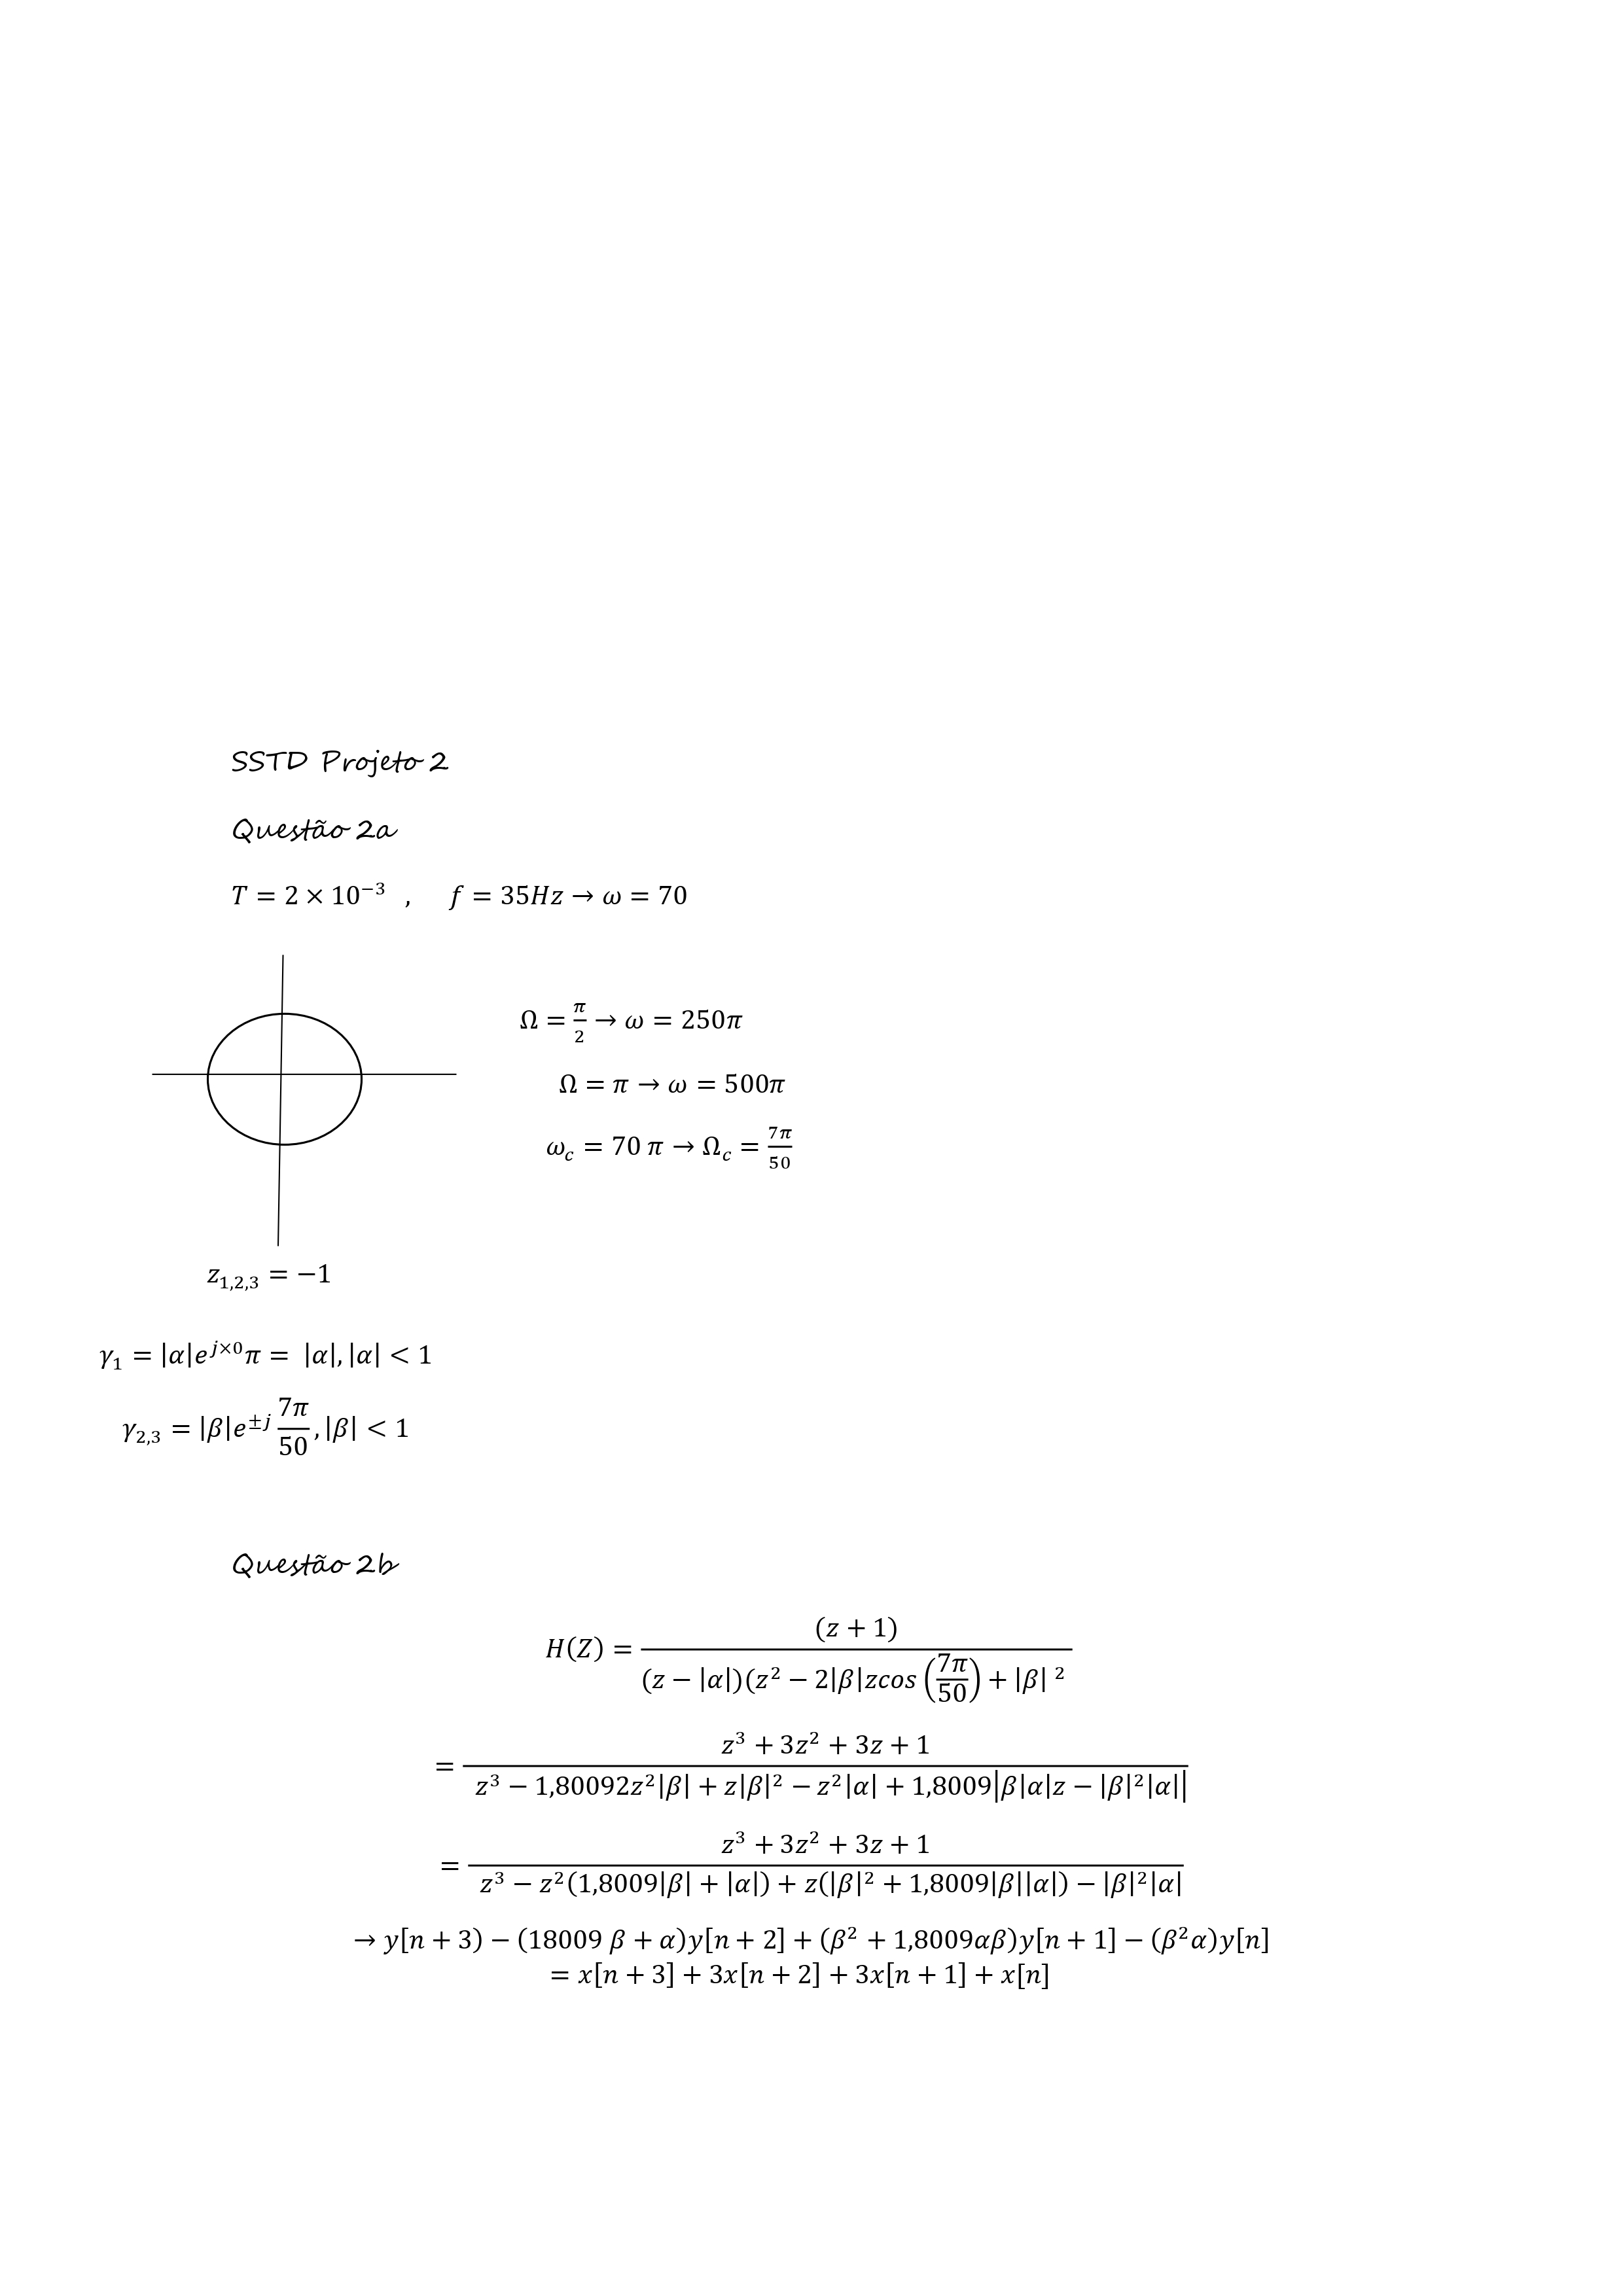

In [ ]:
# Resposta da questão 2b
Image.open("./2a,b.jpg")





## Questão 2c (1  ponto)

Plote a **resposta em frequência** do filtro projetado (magnitude e fase).

<>:48: SyntaxWarning: invalid escape sequence '\O'
<>:49: SyntaxWarning: invalid escape sequence '\O'
<>:57: SyntaxWarning: invalid escape sequence '\O'
<>:58: SyntaxWarning: invalid escape sequence '\O'
<>:65: SyntaxWarning: invalid escape sequence '\O'
<>:66: SyntaxWarning: invalid escape sequence '\O'
<>:48: SyntaxWarning: invalid escape sequence '\O'
<>:49: SyntaxWarning: invalid escape sequence '\O'
<>:57: SyntaxWarning: invalid escape sequence '\O'
<>:58: SyntaxWarning: invalid escape sequence '\O'
<>:65: SyntaxWarning: invalid escape sequence '\O'
<>:66: SyntaxWarning: invalid escape sequence '\O'
C:\Users\admin\AppData\Local\Temp\ipykernel_16088\3340524400.py:48: SyntaxWarning: invalid escape sequence '\O'
  plt.title("Resposta em Frequência de $H(e^{j\Omega})$")
C:\Users\admin\AppData\Local\Temp\ipykernel_16088\3340524400.py:49: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel("Frequência angular $\Omega$")
C:\Users\admin\AppData\Local\Temp\ipykernel_16088\3340524400.p

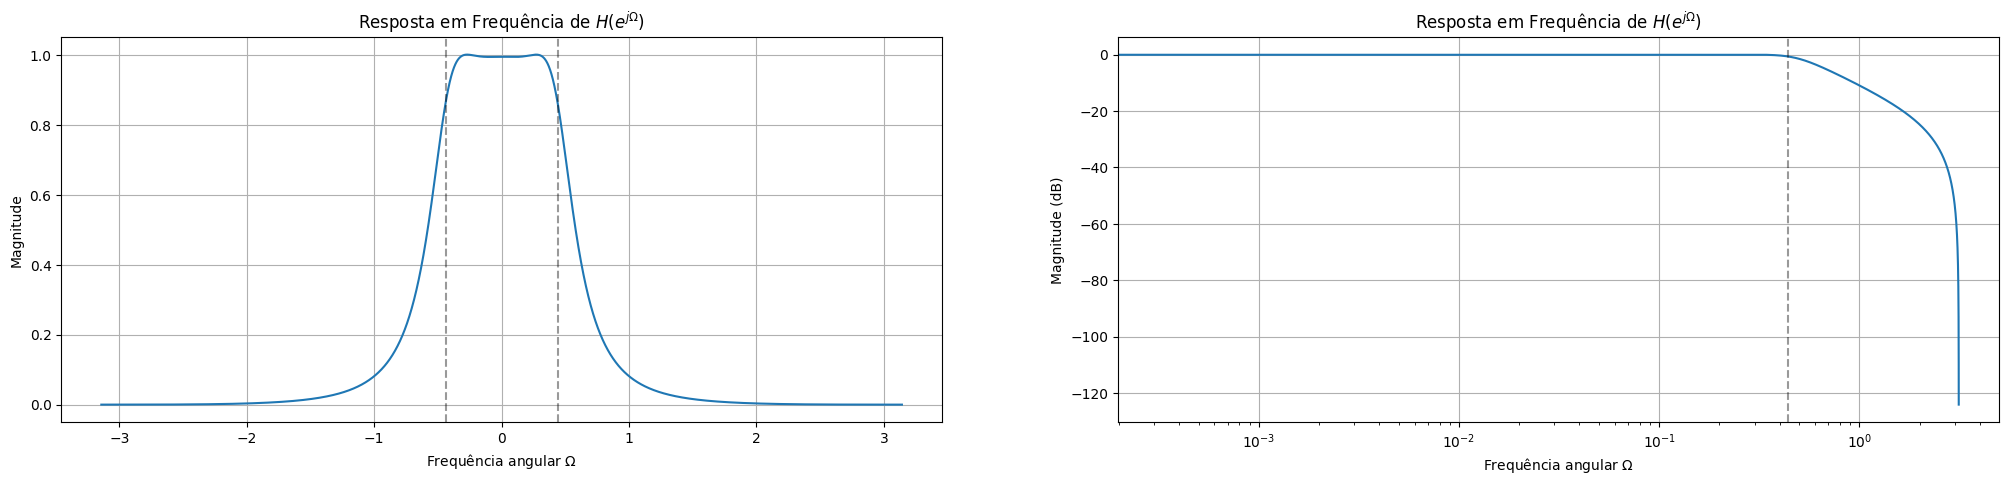

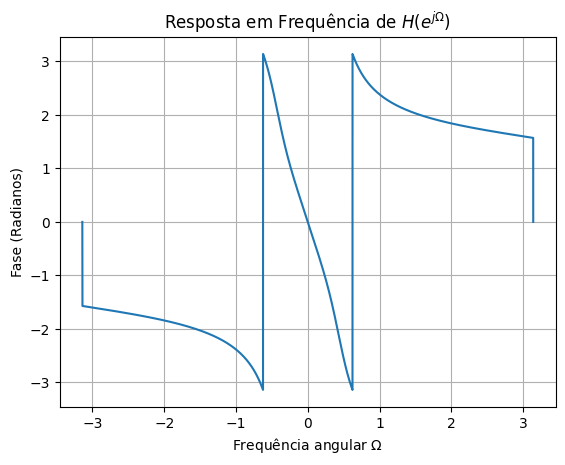

In [5]:
# Resposta questão 2c

# Coeficientes do filtro
ALPHA = 0.65
BETA = 0.82

# Frequência de corte
wc = 7 / 50 * np.pi

# Coeficientes do numerador e denominador
coeficientes_numerador = np.array([1, 3, 3, 1])
coeficientes_denominador = np.array([1, -(2 * np.cos(wc) * BETA + ALPHA),
                                     +(2 * np.cos(wc) * ALPHA * BETA + BETA**2),
                                     -(BETA**2) * ALPHA])

# Frequência de amostragem
z = np.exp(1j * wc / 2)

## Constante para o ganho do filtro ser unitário
k = np.abs(((z + 1) ** 3) /
           ((z - ALPHA) * (z - BETA * np.exp(1j * wc)) * (z - BETA * np.exp(-1j * wc)))) ** (-1)

# Vetor de frequências
w = np.linspace(-np.pi, np.pi, 10000)
w_axis = np.exp(1j * w)

# Função para calcular a resposta em frequência
def calcular_resposta_em_frequencia(coef_num, coef_den, freq_axis):
    numerador = np.polyval(coef_num, freq_axis)
    denominador = np.polyval(coef_den, freq_axis)
    return numerador / denominador

# Calculando a resposta em frequência
H = k * calcular_resposta_em_frequencia(coeficientes_numerador, coeficientes_denominador, w_axis)

# Calculando magnitude, fase e magnitude em dB
H_abs = abs(H)
H_phase = np.angle(H)
H_mag_db = 10 * np.log10(np.abs(H))

# Plotando os resultados
plt.figure(figsize=(25, 5))
plt.subplot(1, 2, 1)
plt.plot(w, H_abs)
plt.axvline(x=wc, linestyle="--", color="black", alpha=0.4)
plt.axvline(x=-wc, linestyle="--", color="black", alpha=0.4)
plt.title("Resposta em Frequência de $H(e^{j\Omega})$")
plt.xlabel("Frequência angular $\Omega$")
plt.ylabel("Magnitude")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(w, H_mag_db)
plt.axvline(x=wc, linestyle="--", color="black", alpha=0.4)
plt.axvline(x=-wc, linestyle="--", color="black", alpha=0.4)
plt.title("Resposta em Frequência de $H(e^{j\Omega})$")
plt.xlabel("Frequência angular $\Omega$")
plt.ylabel("Magnitude (dB)")
plt.xscale("log")
plt.grid()
plt.show()

plt.plot(w, H_phase)
plt.title("Resposta em Frequência de $H(e^{j\Omega})$")
plt.xlabel("Frequência angular $\Omega$")
plt.ylabel("Fase (Radianos)")
plt.grid()
plt.show()




## Questão 2d (0.5  pontos)

Carregue o sinal de ECG "noisy_ecg_data_2.mat" e aplique o filtro projetado neste sinal. Plote o sinal antes da filtragem (x[n]) e o sinal após a filtragem (y[n]).

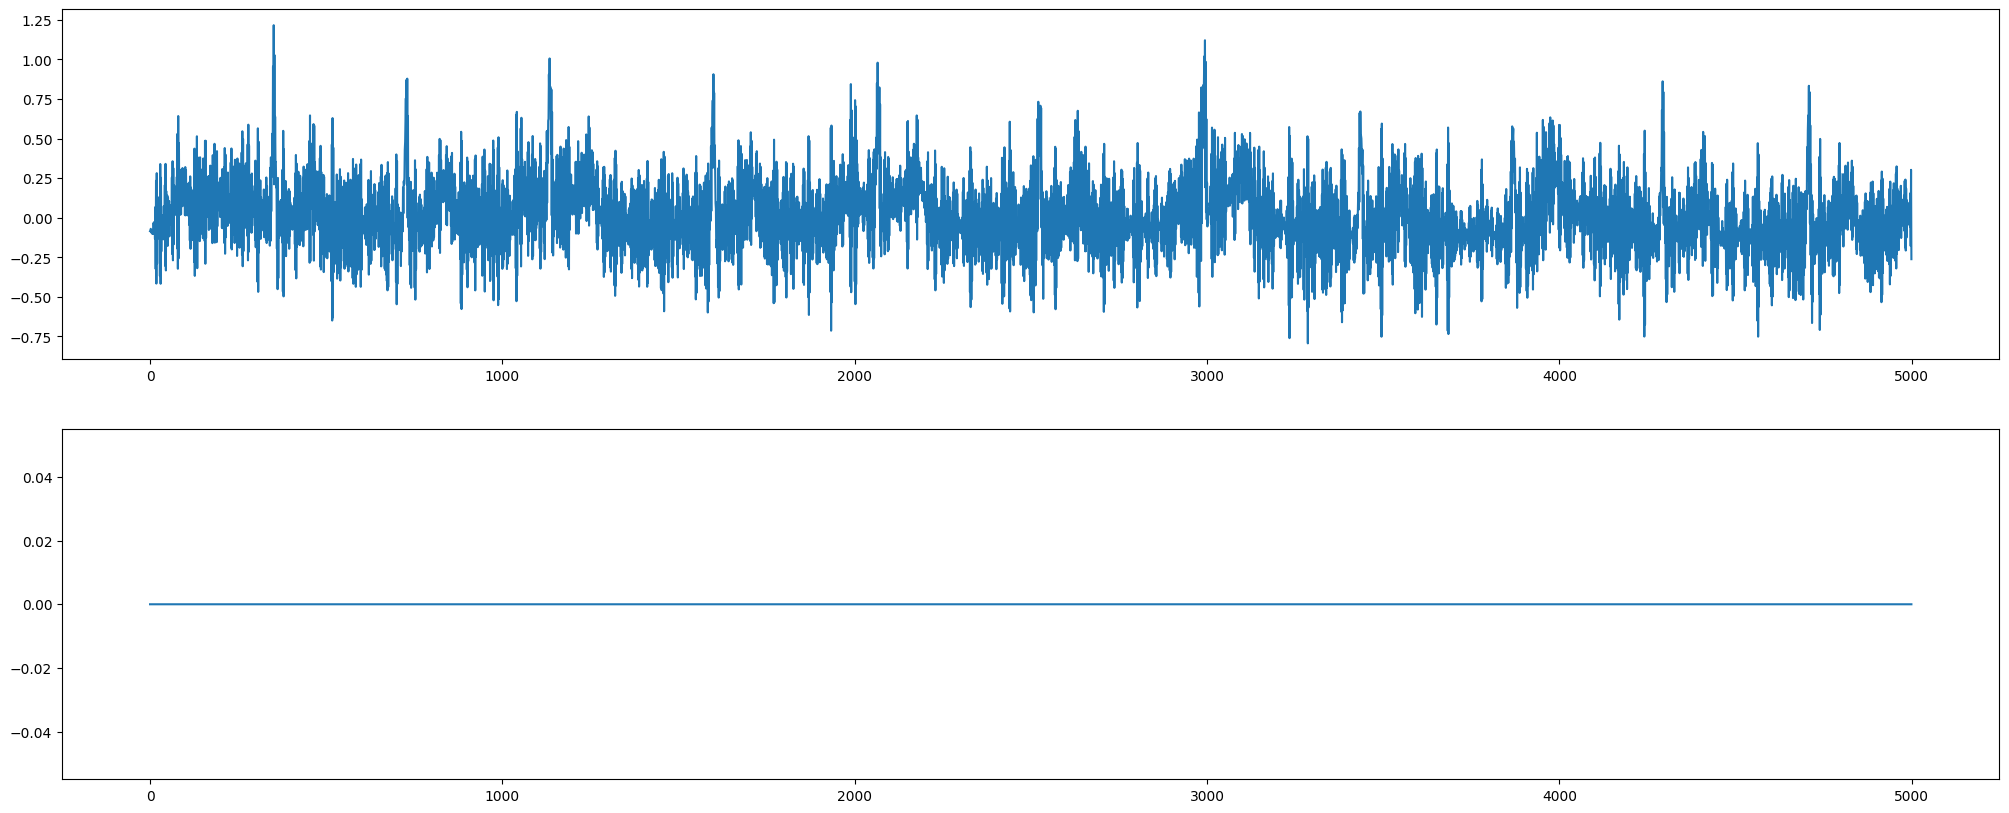

In [ ]:
# Resposta da questão 2d

sinal = sp.io.loadmat("noisy_ecg_data_2.mat")["noisy_ecg2"].ravel()

x_2d = [sinal[n] for n in range(len(sinal))]

restaurar_matriz_recursiva()

y_2d_signal = [y_2d(n, x_2d) for n in range(len(sinal))]

plt.figure(figsize=(25, 10))

plt.subplot(2, 1, 1)
plt.plot(x_2d)


plt.subplot(2, 1, 2)
plt.plot(y_2d_signal)















# Questão 3

Considere o filtro analógico:

$$ H_a \left(s\right) = \frac{\omega_c}{\omega_c + s}$$

E considere o valor:

$$\omega_c = 10^3 $$

## Questão 3a (1  ponto)

Projete uma aproximação digital para este filtro com critério de 10%. Indique a taxa de amostragem calculada para esta aproximação (T1) e compare a resposta em frequência do filtro projetado H1() com a resposta em frequência do filtro analógic Ha(). Plote as frequências até ao menos:

$$ \omega = 10^5 \pi $$

<>:43: SyntaxWarning: invalid escape sequence '\o'
<>:44: SyntaxWarning: invalid escape sequence '\O'
<>:46: SyntaxWarning: invalid escape sequence '\o'
<>:46: SyntaxWarning: invalid escape sequence '\o'
<>:43: SyntaxWarning: invalid escape sequence '\o'
<>:44: SyntaxWarning: invalid escape sequence '\O'
<>:46: SyntaxWarning: invalid escape sequence '\o'
<>:46: SyntaxWarning: invalid escape sequence '\o'
C:\Users\admin\AppData\Local\Temp\ipykernel_17456\134480506.py:43: SyntaxWarning: invalid escape sequence '\o'
  plt.title("Respostas em Frequência de $H[e^{j\omega}]$ e $H_{a}(j\omega)$")
C:\Users\admin\AppData\Local\Temp\ipykernel_17456\134480506.py:44: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel("Frequência angular $\Omega$")
C:\Users\admin\AppData\Local\Temp\ipykernel_17456\134480506.py:46: SyntaxWarning: invalid escape sequence '\o'
  plt.legend(["$H[e^{j\omega}]$", "$H_{a}(j\omega)$"])
C:\Users\admin\AppData\Local\Temp\ipykernel_17456\134480506.py:46: SyntaxWarning: 

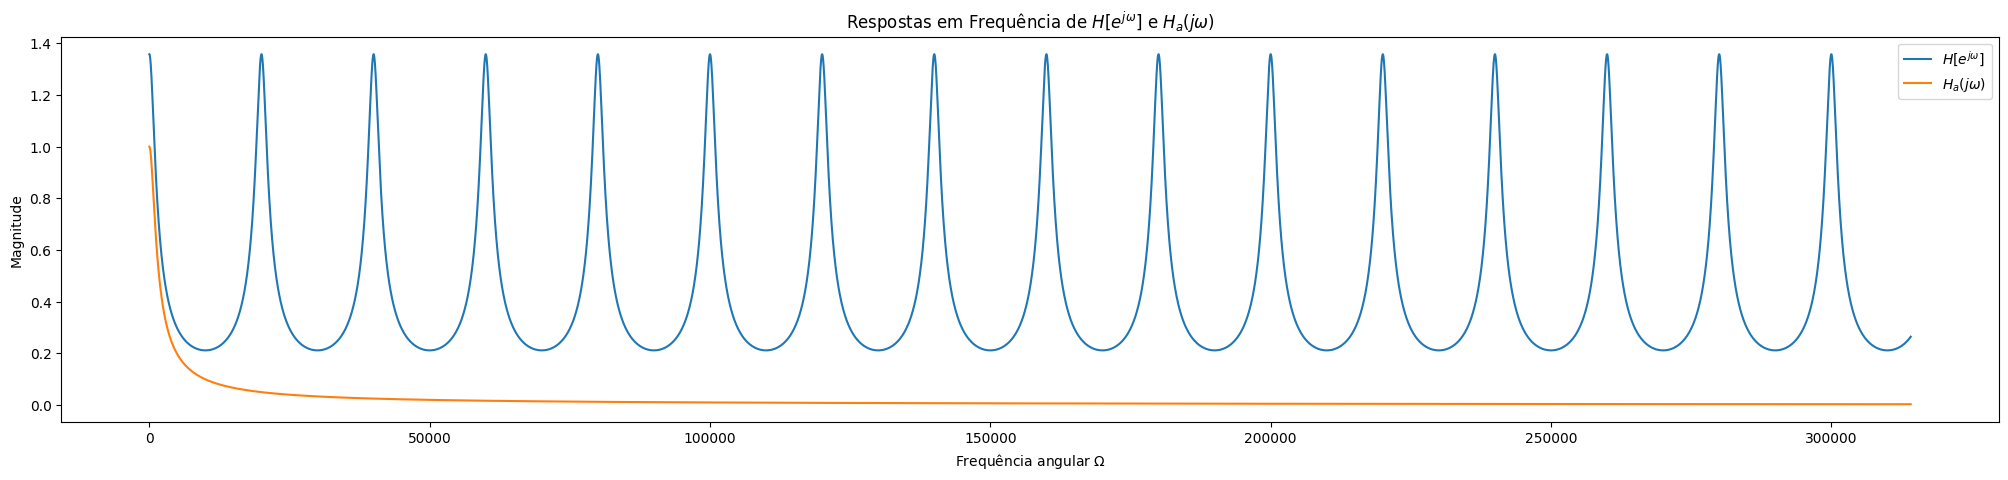

In [ ]:
# Resposta da questão 3a

# Definição dos coeficientes
a0, a1 = 1, -np.exp(-10**3 * 10**(-4) * np.pi)
b0, b1 = 10**3 * 10**(-4) * np.pi, 0

# Valores de frequência
w = np.linspace(0, 10**5 * np.pi, 10000)

# Função para calcular k1
def calcular_k1():
    numerador = (b0 * 1 + b1)
    denominador = (a0 * 1 + a1)
    return numerador / denominador

# Função para calcular H1
def calcular_h1(w):
    k1 = calcular_k1()
    w_axis = np.exp(1j * 10**(-4) * np.pi * w)
    numerador = k1 * (b0 * w_axis + b1)
    denominador = a0 * w_axis + a1
    return numerador / denominador

# Função para calcular Ha1
def calcular_ha1(w):
    wc = 10**3
    numerador = wc
    denominador = 1j * w + wc
    return numerador / denominador


# Cálculo das respostas em frequência
H1_abs = np.abs(calcular_h1(w))
Ha1_abs = np.abs(calcular_ha1(w))


# Plotagem dos resultados
plt.figure(figsize=(25, 5))
plt.plot(w, H1_abs)
plt.plot(w, Ha1_abs)
plt.title("Respostas em Frequência de $H[e^{j\omega}]$ e $H_{a}(j\omega)$")
plt.xlabel("Frequência angular $\Omega$")
plt.ylabel("Magnitude")
plt.legend(["$H[e^{j\omega}]$", "$H_{a}(j\omega)$"])
plt.show()




## Questão 3b (1  ponto)

Projete uma aproximação digital para este filtro com critério de 1%. Indique a taxa de amostragem calculada para esta aproximação (T2) e compare a resposta em frequência do filtro projetado H2() com a resposta em frequência do filtro analógic Ha(). Plote as frequências até ao menos:

$$ \omega = 10^5 \pi $$

<>:24: SyntaxWarning: invalid escape sequence '\o'
<>:26: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\O'
<>:24: SyntaxWarning: invalid escape sequence '\o'
<>:26: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\O'
C:\Users\admin\AppData\Local\Temp\ipykernel_16088\3753674992.py:24: SyntaxWarning: invalid escape sequence '\o'
  plt.plot(w, H2_abs, label="$|H[e^{j\omega}]|$")
C:\Users\admin\AppData\Local\Temp\ipykernel_16088\3753674992.py:26: SyntaxWarning: invalid escape sequence '\o'
  plt.title("Respostas em Frequência de $H[e^{j\omega}]$ e $H_{a}(j\omega)$")
C:\Users\admin\AppData\Local\Temp\ipykernel_16088\3753674992.py:27: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel("Frequência angular $\Omega$")


Taxa de amostragem: 0.031415926535897934 ms


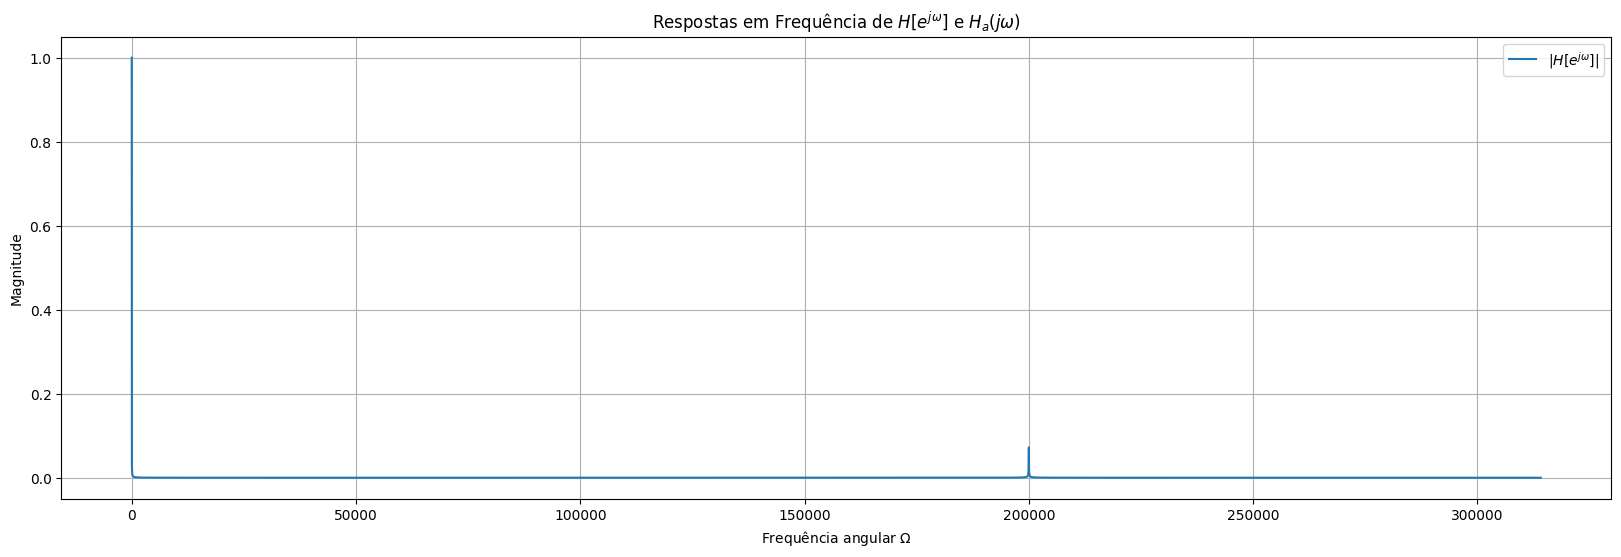

In [7]:
# Resposta da questão 3b

T2 = 10 ** (-5) * np.pi
print(f"Taxa de amostragem: {T2*10**(3)} ms")

wc = 1  # Definindo wc arbitrariamente

a0 = 1
a1 = -np.exp(-wc * T2)
b0 = wc * T2
b1 = 0

k2 = ((b0 * 1 + b1) / (a0 * 1 + a1)) ** (-1)

w = np.linspace(0, 10**5 * np.pi, 10000)
w_axis = np.exp(1j * T2 * w)

H2 = k2 * (b0 * w_axis + b1) / (a0 * w_axis + a1)
H2_abs = np.abs(H2)

plt.figure(figsize=(20, 6))

# Plota a magnitude de H[e^(jw)]
plt.plot(w, H2_abs, label="$|H[e^{j\omega}]|$")

plt.title("Respostas em Frequência de $H[e^{j\omega}]$ e $H_{a}(j\omega)$")
plt.xlabel("Frequência angular $\Omega$")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)
plt.show()






## Questão 3c (1 ponto)

Calcule a resposta ao impulso ha(t) do filtro analógico Ha(s), bem como as respostas ao impulso h1[n] e h2[n] dos filtros projetados H1(z) e H2(z). **Plote** as respostas ao impulso na mesma escala.

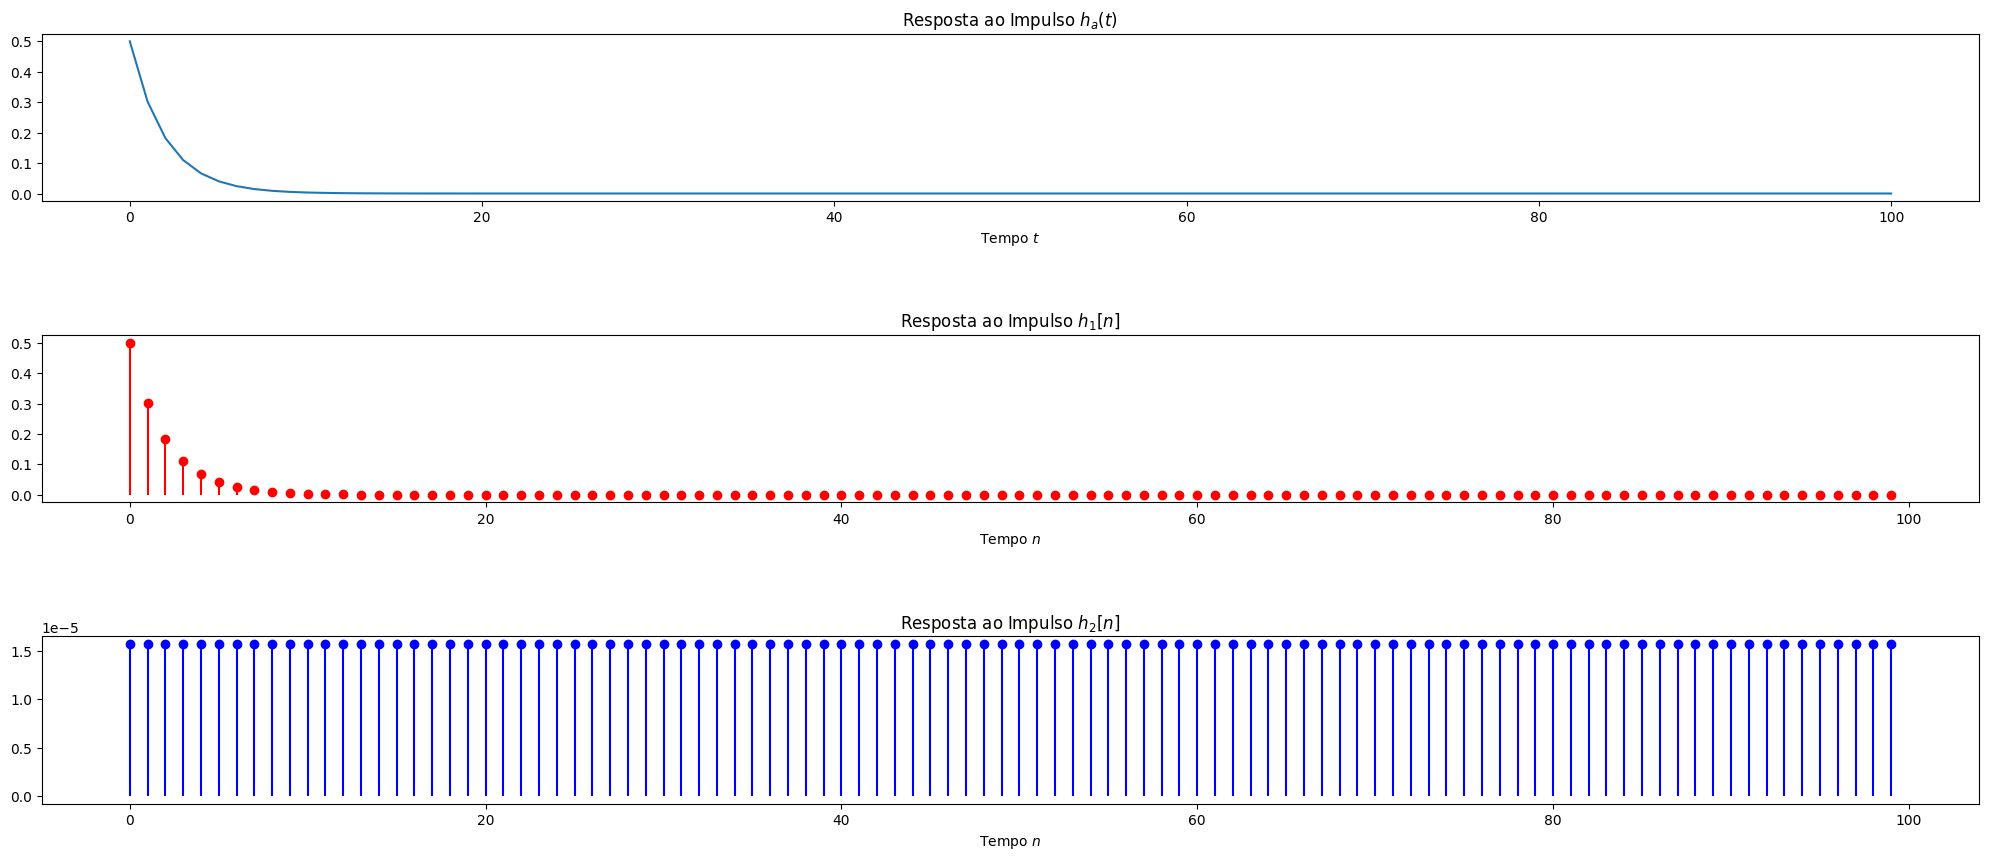

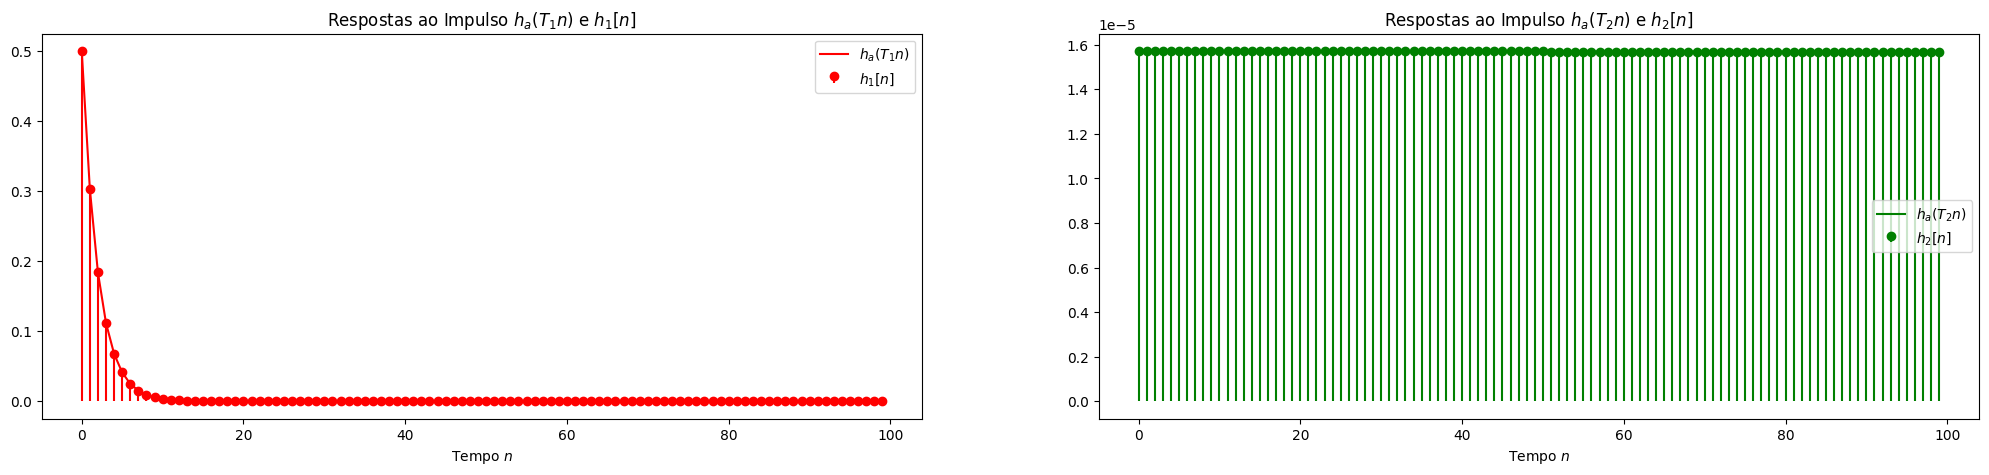

In [8]:
# Resposta da questão 3c

def ha_3c(t, wc):
    return wc * np.exp(-wc * t) * np.heaviside(t, 1)

# Definindo os parâmetros
T1 = 1
T2 = 10 ** (-5) * np.pi
wc = 0.5  # Defina wc como o valor apropriado

# Tempo e índices
t = np.linspace(0, 100, 100)
n = np.arange(0, 100)

# Respostas ao impulso
ha_t = ha_3c(t, wc)
ha_1_n = ha_3c(T1 * n, wc)
ha_2_n = ha_3c(T2 * n, wc)
h1_n = T1 * wc * np.exp(-wc * T1 * n)
h2_n = T2 * wc * np.exp(-wc * T2 * n)

# Plotagem
plt.figure(figsize=(25, 10))

plt.subplot(3, 1, 1)
plt.plot(t, ha_t)
plt.xlabel("Tempo $t$")
plt.title("Resposta ao Impulso $h_{a}(t)$")

plt.subplot(3, 1, 2)
plt.stem(n, h1_n, linefmt="r-", markerfmt="ro", basefmt=" ")
plt.xlabel("Tempo $n$")
plt.title("Resposta ao Impulso $h_{1}[n]$")

plt.subplot(3, 1, 3)
plt.stem(n, h2_n, linefmt="b-", markerfmt="bo", basefmt=" ")
plt.xlabel("Tempo $n$")
plt.title("Resposta ao Impulso $h_{2}[n]$")

plt.subplots_adjust(hspace=0.8)
plt.show()

plt.figure(figsize=(25, 5))

plt.subplot(1, 2, 1)
plt.plot(n, ha_1_n * T1, 'r-')
plt.stem(n, h1_n, linefmt="r-", markerfmt="ro", basefmt=" ")
plt.xlabel("Tempo $n$")
plt.title("Respostas ao Impulso $h_{a}(T_1n)$ e $h_{1}[n]$")
plt.legend(["$h_{a}(T_1n)$", "$h_{1}[n]$"])

plt.subplot(1, 2, 2)
plt.plot(n, ha_2_n * T2, 'g-')
plt.stem(n, h2_n, linefmt="g-", markerfmt="go", basefmt=" ")
plt.xlabel("Tempo $n$")
plt.title("Respostas ao Impulso $h_{a}(T_2n)$ e $h_{2}[n]$")
plt.legend(["$h_a(T_2n)$", "$h_{2}[n]$"])

plt.show()



## Questão 3d (2 pontos)

Considere o sinal:
$$ x\left(t\right) = e^{- \lambda t} u\left(t\right)$$

com

$$\lambda = 500 $$

Calcule a resposta teórica do filtro analógico, y(t), bem como a resposta do filtro digital H1(z) ao sinal amostrado com taxa T1 (x1[n]) e a resposta do filtro digital H2(z) ao sinal amostrado com taxa T2 (x2[n]). **Plote**, na mesma escala, o sinal y(t) e as aproximações y1[n] e y2[n].

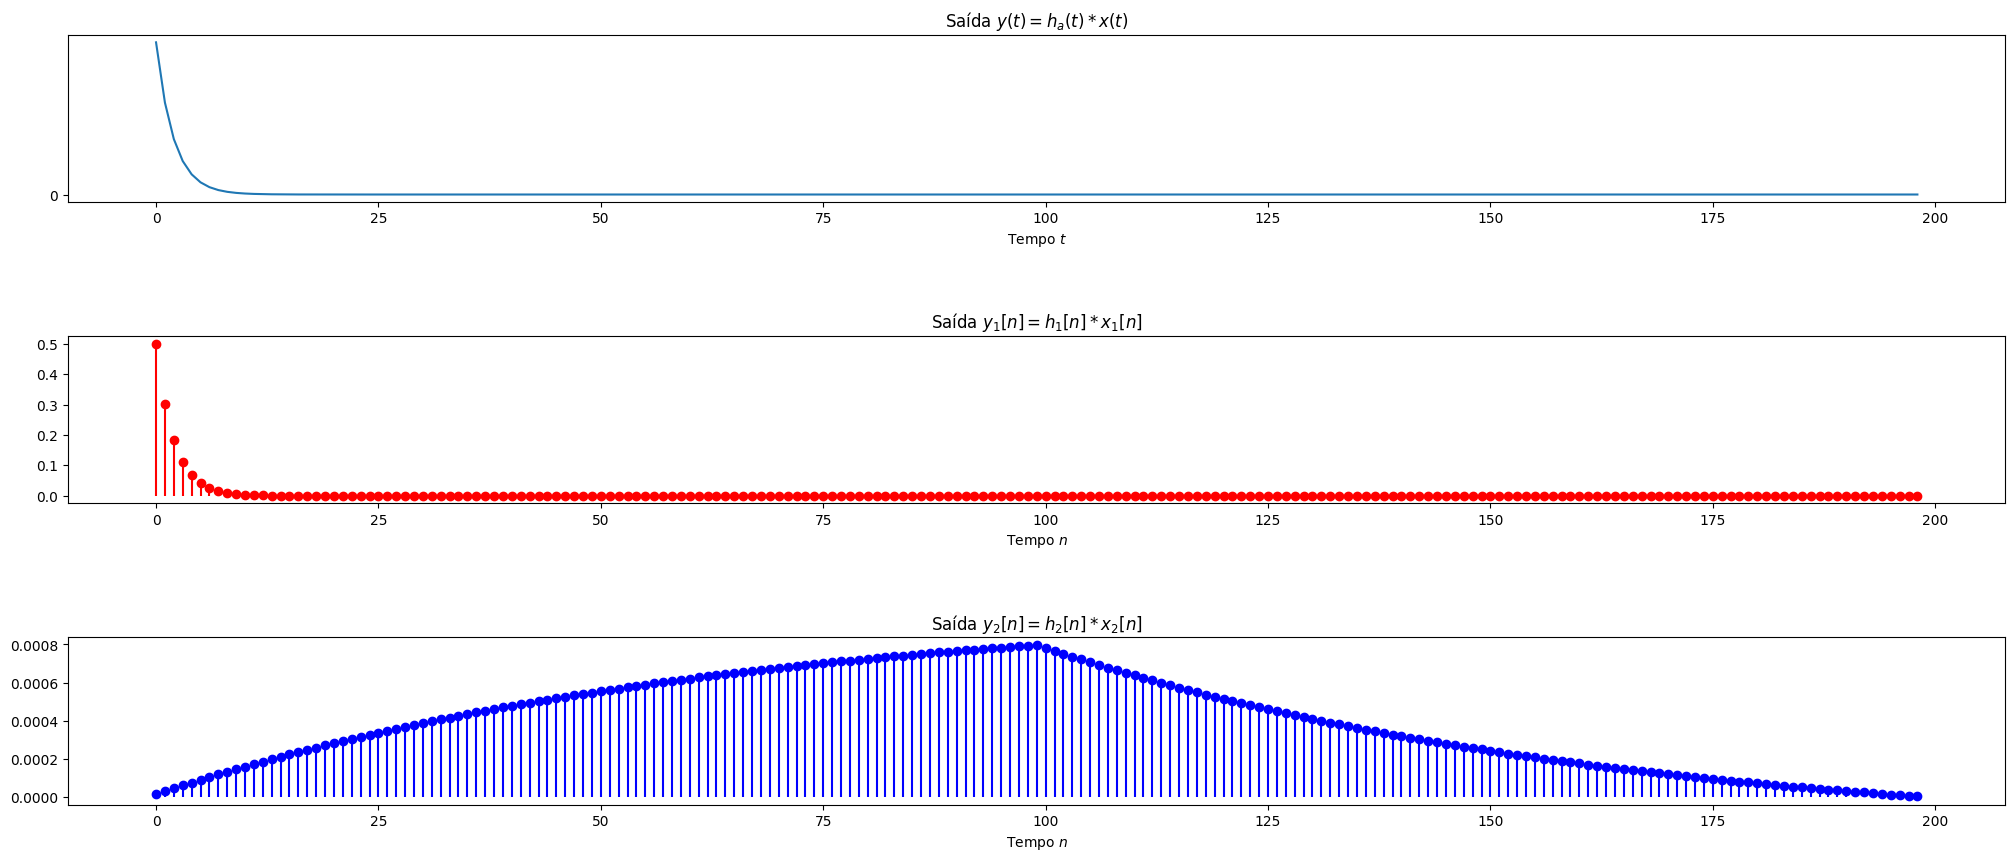

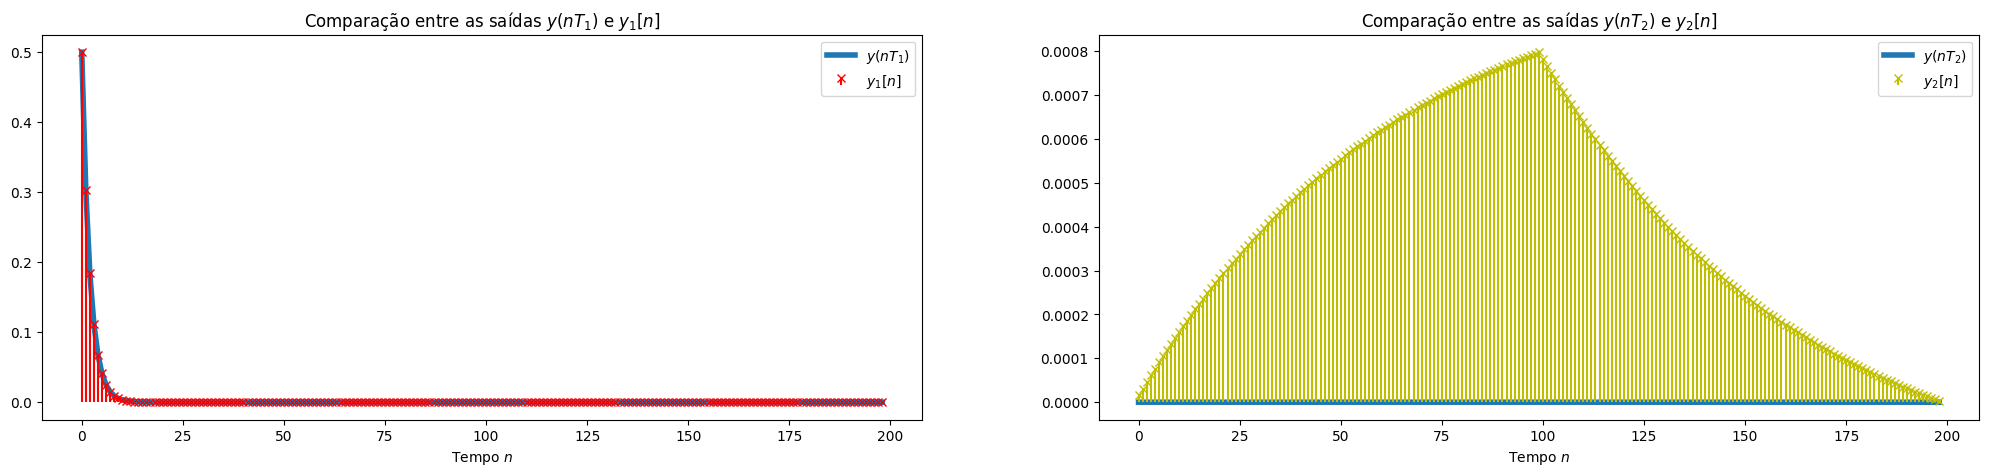

In [9]:
# Resposta da questão 3d

# Definição das funções
def ha_3c(t, wc):
    return wc * np.exp(-wc * t) * np.heaviside(t, 1)

def xa_3d(t):
    return np.exp(-500 * t) * np.heaviside(t, 1)

def ya_3d(t, ha, wc):
    return np.convolve(ha, xa_3d(t), mode="full")

# Definição das variáveis
T1 = 1
T2 = 10 ** (-5) * np.pi
n = np.arange(0, 100)
t = np.linspace(0, 100, 100)
wc = 0.5  # Defina wc como o valor apropriado

# Cálculo das respostas ao impulso
ha_1_3c = ha_3c(T1 * n, wc)
ha_2_3c = ha_3c(T2 * n, wc)

# Cálculo de x1_3d e x2_3d
x1_3d = T1 * np.exp(-500 * T1 * n)
x2_3d = T2 * np.exp(-500 * T2 * n)

# Cálculo de y1_3d e y2_3d
ya_0_3d = ya_3d(t, ha_3c(t, wc), wc)
ya_1_3d = ya_3d(T1 * n, ha_1_3c, wc)
ya_2_3d = ya_3d(T2 * n, ha_2_3c, wc)
y1_3d = np.convolve(ha_1_3c, x1_3d, mode="full")
y2_3d = np.convolve(ha_2_3c, x2_3d, mode="full")

# Plotagem
plt.figure(figsize=(25, 10))

plt.subplot(3, 1, 1)
plt.plot(ya_0_3d)
plt.title("Saída $y(t) = h_{a}(t) * x(t)$")
plt.xlabel("Tempo $t$")
plt.yticks(np.arange(0, max(ya_0_3d), step=(150)))

plt.subplot(3, 1, 2)
plt.stem(y1_3d, linefmt="r-", markerfmt="ro", basefmt=" ")
plt.title("Saída $y_{1}[n] = h_{1}[n] * x_{1}[n]$")
plt.xlabel("Tempo $n$")

plt.subplot(3, 1, 3)
plt.stem(y2_3d, linefmt="b-", markerfmt="bo", basefmt=" ")
plt.title("Saída $y_{2}[n] = h_{2}[n] * x_{2}[n]$")
plt.xlabel("Tempo $n$")
plt.subplots_adjust(hspace=0.8)

plt.show()

plt.figure(figsize=(25, 5))

plt.subplot(1, 2, 1)
plt.plot(ya_1_3d * T1**2, linewidth=4)
plt.stem(y1_3d, linefmt="r-", markerfmt="rx", basefmt=" ")
plt.title("Comparação entre as saídas $y(nT_1)$ e $y_{1}[n]$")
plt.legend(["$y(nT_1)$", "$y_{1}[n]$"])
plt.xlabel("Tempo $n$")

plt.subplot(1, 2, 2)
plt.plot(ya_2_3d * T2**2, linewidth=4)
plt.stem(y2_3d, linefmt="y-", markerfmt="yx", basefmt=" ")
plt.title("Comparação entre as saídas $y(nT_2)$ e $y_{2}[n]$")
plt.legend(["$y(nT_2)$", "$y_{2}[n]$"])
plt.xlabel("Tempo $n$")

plt.show()




